# Lab Data Preparation : Adult Census Income
## Ciblage marketing de produits bancaires premium

**Sommaire**
1. Business Understanding
2. Data Understanding
3. Data Exploration
4. Data Preparation (nettoyage + transformation)
5. Segmentation
6. Classification
7. Évaluation et interprétation

> **Pour exécuter :** *Exécution > Tout exécuter*. Les données sont téléchargées automatiquement
> depuis le site de l'UCI (cellule 2.1), rien à téléverser.

## 1. Business Understanding

### Contexte
Une banque souhaite développer la vente de ses produits premium (cartes haut de gamme, placements,
gestion de patrimoine). Or elle ne connaît pas le revenu de la majorité de ses prospects : cette
information est sensible et rarement déclarée. Les campagnes actuelles, envoyées à tous, ont un
faible taux de conversion et un coût élevé.

### Problématique
Comment identifier, à partir d'informations socio-professionnelles facilement disponibles (âge, diplôme,
métier, situation familiale, temps de travail…), les prospects ayant un potentiel de revenu élevé, et
comment adapter l'offre à chaque type de clientèle ?

### Business Objectives
- **BO1** : augmenter le taux de conversion des campagnes premium en ciblant les prospects les plus
  susceptibles d'avoir un revenu élevé.
- **BO2** : réduire les coûts marketing en évitant de solliciter des prospects non éligibles.
- **BO3** : personnaliser les offres selon des profils de clientèle homogènes.

### Data Science Objectives
- **DSO1 (classification)** : prédire si un individu gagne plus de 50 000 $ par an
  (variable `income`, classes `<=50K` / `>50K`).
- **DSO2 (segmentation)** : regrouper les individus en segments homogènes selon leur profil
  socio-professionnel, puis décrire chaque segment pour orienter l'offre.

### Critères de succès
- **Classification** : rappel ≥ 75 % sur la classe `>50K` (ne pas manquer les bons prospects), avec un
  F1-score et une AUC supérieurs à un modèle de référence simple. L'accuracy seule n'est pas retenue
  car les classes sont déséquilibrées.
- **Segmentation** : segments bien séparés (score de silhouette) et surtout interprétables métier,
  c'est-à-dire qu'on peut associer une offre concrète à chaque segment.

### Contraintes et risques
- Données de 1994 (recensement américain) : les seuils de revenu et la structure des métiers ont
  changé ; le projet a une valeur démonstrative de la démarche.
- Éthique et réglementation : cibler des clients selon leur sexe ou leur origine est discriminatoire.
  Le modèle sera évalué avec et sans les variables sensibles (`sex`, `race`, ainsi que `relationship`
  et `native_region` qui les révèlent indirectement) afin de mesurer leur apport réel
  et de proposer un modèle déployable.
- `fnlwgt` est un poids statistique du recensement et non une caractéristique du client : il ne sera
  pas utilisé comme variable prédictive.

## 2. Data Understanding

### 2.1 Imports et paramètres

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

# Reproductibilité : à utiliser par toute l'équipe
RANDOM_STATE = 42

# Dossier contenant adult.data et adult.test
DATA_DIR = "."

# Téléchargement automatique des données si elles ne sont pas déjà présentes
import urllib.request, zipfile
if not os.path.exists(os.path.join(DATA_DIR, "adult.data")):
    urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/2/adult.zip", "adult.zip")
    zipfile.ZipFile("adult.zip").extractall(DATA_DIR)
print([f for f in os.listdir(DATA_DIR) if f.startswith("adult")])

['adult.data', 'adult_preparation_banque.ipynb', 'adult_data_preparation.ipynb', 'adult.test']


### 2.2 Chargement des données

Les fichiers n'ont **pas de ligne d'en-tête** : les noms de colonnes sont donnés dans `adult.names`.
Trois pièges de format sont corrigés dès le chargement :
- les valeurs sont séparées par `", "` : l'espace après la virgule est retiré avec `skipinitialspace=True` ;
- la première ligne de `adult.test` (`|1x3 Cross validator`) n'est pas une donnée : on la saute ;
- dans `adult.test`, les étiquettes se terminent par un point (`>50K.`) : on le retire pour avoir
  les mêmes classes que dans `adult.data`.

On **conserve volontairement les `?`** à ce stade pour pouvoir les mesurer pendant l'exploration ;
ils seront traités dans la partie Data Preparation.

In [2]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]

train_raw = pd.read_csv(os.path.join(DATA_DIR, "adult.data"),
                        names=COLUMNS, skipinitialspace=True)
test_raw = pd.read_csv(os.path.join(DATA_DIR, "adult.test"),
                       names=COLUMNS, skipinitialspace=True, skiprows=1)

# Harmonisation des étiquettes du fichier test
test_raw["income"] = test_raw["income"].str.rstrip(".")

print("Train :", train_raw.shape)
print("Test  :", test_raw.shape)
print("Classes train :", sorted(train_raw["income"].unique()))
print("Classes test  :", sorted(test_raw["income"].unique()))

Train : (32561, 15)
Test  : (16281, 15)
Classes train : ['<=50K', '>50K']
Classes test  : ['<=50K', '>50K']


On réunit les deux fichiers dans un seul DataFrame `df_raw`, en gardant une colonne `source`.
Cela permet de décrire et nettoyer l'ensemble des données de façon homogène, **tout en conservant
le découpage officiel train/test** pour la classification.

> **Règle d'équipe** : `df_raw` n'est jamais modifié. Chaque étape suivante travaille sur une copie
> (`df_clean`, `df_prep`…). Toute statistique utilisée pour transformer les données (médiane, moyenne,
> écart-type…) sera calculée **sur le train uniquement**, pour éviter la fuite de données.

In [3]:
df_raw = pd.concat(
    [train_raw.assign(source="train"), test_raw.assign(source="test")],
    ignore_index=True,
)
print(df_raw.shape)
df_raw.head()

(48842, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


### 2.3 Structure du dataset

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  48842 non-null  str  
 14  income          48842 non-null  str  
 15  source          48842 non-null  str  
dtypes: int64(6), str(10)
memory usage: 6.0 MB


### 2.4 Dictionnaire des variables

| Variable | Type | Description |
|---|---|---|
| `age` | numérique | âge de l'individu |
| `workclass` | catégorielle | secteur d'emploi (privé, public, indépendant…) |
| `fnlwgt` | numérique | poids d'échantillonnage du recensement (nombre de personnes que représente la ligne) |
| `education` | catégorielle | diplôme le plus élevé |
| `education_num` | numérique (ordinale) | diplôme codé de 1 (Preschool) à 16 (Doctorate) |
| `marital_status` | catégorielle | situation matrimoniale |
| `occupation` | catégorielle | catégorie de métier |
| `relationship` | catégorielle | rôle dans le foyer |
| `race` | catégorielle | origine ethnique (variable sensible) |
| `sex` | catégorielle | sexe (variable sensible) |
| `capital_gain` | numérique | plus-values en capital |
| `capital_loss` | numérique | moins-values en capital |
| `hours_per_week` | numérique | heures travaillées par semaine |
| `native_country` | catégorielle | pays d'origine |
| `income` | **cible** | `<=50K` ou `>50K` |

In [5]:
num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
cat_cols = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country"]
target = "income"

# Cible binaire (1 = >50K) utile pour calculer des taux dans l'exploration
df_raw["y"] = (df_raw[target] == ">50K").astype(int)

df_raw[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.64,13.71,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.13,105604.03,12285.0,117550.5,178144.5,237642.0,1490400.0
education_num,48842.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital_gain,48842.0,1079.07,7452.02,0.0,0.0,0.0,0.0,99999.0
capital_loss,48842.0,87.50,403.00,0.0,0.0,0.0,0.0,4356.0
hours_per_week,48842.0,40.42,12.39,1.0,40.0,40.0,45.0,99.0


In [6]:
# Nombre de modalités de chaque variable catégorielle
df_raw[cat_cols].nunique().sort_values(ascending=False)

native_country    42
education         16
occupation        15
workclass          9
marital_status     7
relationship       6
race               5
sex                2
dtype: int64

## 3. Data Exploration

### 3.1 Qualité des données

#### Valeurs manquantes
Le dataset ne contient aucun `NaN` au sens de pandas : les valeurs manquantes sont **codées par `?`**.
Il faut donc les chercher explicitement.

In [7]:
missing = pd.DataFrame({
    "nb_?": (df_raw[COLUMNS] == "?").sum(),
    "nb_NaN": df_raw[COLUMNS].isna().sum(),
})
missing["%_?"] = (missing["nb_?"] / len(df_raw) * 100).round(2)
missing[missing["nb_?"] > 0]

,nb_?,nb_NaN,%_?
workclass,2799,0,5.73
occupation,2809,0,5.75
native_country,857,0,1.75


In [8]:
# Les valeurs manquantes sont-elles liées entre elles ?
wc = df_raw["workclass"] == "?"
oc = df_raw["occupation"] == "?"
print("workclass = ?                    :", wc.sum())
print("occupation = ?                   :", oc.sum())
print("les deux à la fois               :", (wc & oc).sum())
print("occupation = ? mais workclass != ?:")
print(df_raw.loc[oc & ~wc, "workclass"].value_counts())

workclass = ?                    : 2799
occupation = ?                   : 2809
les deux à la fois               : 2799
occupation = ? mais workclass != ?:
workclass
Never-worked    10
Name: count, dtype: int64


In [9]:
# Profil d'âge des personnes dont le secteur est inconnu, comparé à l'ensemble
age_bins = [16, 25, 60, 100]
age_labels = ["17-25", "26-60", "61+"]
comparaison = pd.DataFrame({
    "workclass = ?": pd.cut(df_raw.loc[wc, "age"], age_bins, labels=age_labels).value_counts(normalize=True),
    "ensemble": pd.cut(df_raw["age"], age_bins, labels=age_labels).value_counts(normalize=True),
}).round(2)
print(comparaison)
print("\nTaux de >50K si workclass = ? :", round(df_raw.loc[wc, "y"].mean(), 3))
print("Taux de >50K global           :", round(df_raw["y"].mean(), 3))

       workclass = ?  ensemble
age                           
17-25           0.38      0.20
26-60           0.37      0.73
61+             0.25      0.07

Taux de >50K si workclass = ? : 0.095
Taux de >50K global           : 0.239


**Observations**
- 3 variables catégorielles ont des valeurs manquantes : `workclass` (~5,7 %), `occupation` (~5,8 %)
  et `native_country` (~1,8 %).
- Les manques de `workclass` et `occupation` concernent **les mêmes individus**. Les 10 lignes
  supplémentaires sans `occupation` sont des personnes `Never-worked`, pour qui l'absence de métier est logique.
- Ces individus sont **sur-représentés chez les jeunes (≤ 25 ans) et les plus de 60 ans**, et ont un taux de
  hauts revenus bien plus faible (~9 % contre ~24 %). Ce sont probablement des étudiants, retraités ou
  personnes sans emploi.

**Conséquence pour la préparation** : les valeurs ne manquent pas au hasard. Une imputation par le mode
(`Private`, `Prof-specialty`) inventerait un emploi à des personnes qui n'en ont sans doute pas. Il sera
plus juste de créer une modalité `Unknown`, qui conserve cette information.

#### Doublons

In [10]:
nb_dup = df_raw.duplicated(subset=COLUMNS).sum()
print(f"Lignes en double : {nb_dup} ({nb_dup / len(df_raw):.2%})")
df_raw[df_raw.duplicated(subset=COLUMNS, keep=False)].sort_values(COLUMNS).head(6)

Lignes en double : 52 (0.11%)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,y
24667,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K,train,0
36713,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K,test,0
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K,test,0
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K,test,0
10094,19,?,167428,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K,train,0
40677,19,?,167428,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K,test,0


Les doublons sont très peu nombreux. Comme chaque ligne représente une personne interrogée, deux personnes
peuvent avoir exactement le même profil ; mais avec `fnlwgt` (poids quasi unique) identique, il s'agit très
probablement de vrais doublons. Leur suppression sera discutée en Data Preparation (impact négligeable).

#### Valeurs suspectes

In [11]:
print("capital_gain = 99999 :", (df_raw["capital_gain"] == 99999).sum(),
      "| taux de >50K :", df_raw.loc[df_raw["capital_gain"] == 99999, "y"].mean())
print("hours_per_week = 99  :", (df_raw["hours_per_week"] == 99).sum())
print("age = 90             :", (df_raw["age"] == 90).sum())
print("capital_gain > 0 ET capital_loss > 0 :",
      ((df_raw["capital_gain"] > 0) & (df_raw["capital_loss"] > 0)).sum())

capital_gain = 99999 : 244 | taux de >50K : 1.0
hours_per_week = 99  : 137
age = 90             : 55
capital_gain > 0 ET capital_loss > 0 : 0


**Observations**
- **`capital_gain = 99999`** : valeur plafond utilisée par le recensement (codage de type « 99999 ou plus »),
  et non un montant réel. Tous ces individus sont `>50K` : l'information est réelle, c'est la valeur qui est artificielle.
- **`hours_per_week = 99`** : probablement aussi un plafond de saisie. Plausible pour certains métiers, à surveiller.
- **`age = 90`** : regroupement probable des personnes de 90 ans et plus.
- Personne n'a à la fois une plus-value et une moins-value : les deux variables pourraient être combinées
  en une seule (`capital_net`) lors du feature engineering.

### 3.2 Variable cible

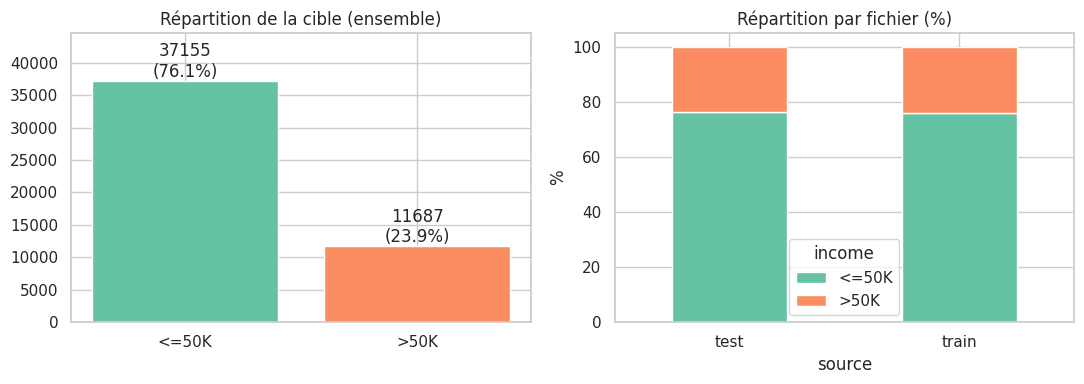

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df_raw[target].value_counts()
ax[0].bar(counts.index, counts.values, color=["#66c2a5", "#fc8d62"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v}\n({v / len(df_raw):.1%})", ha="center", va="bottom")
ax[0].set_title("Répartition de la cible (ensemble)")
ax[0].set_ylim(0, counts.max() * 1.2)

(pd.crosstab(df_raw["source"], df_raw[target], normalize="index") * 100).plot(
    kind="bar", stacked=True, ax=ax[1], color=["#66c2a5", "#fc8d62"])
ax[1].set_title("Répartition par fichier (%)")
ax[1].set_ylabel("%")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Observations**
- Les classes sont **déséquilibrées** : environ 76 % `<=50K` contre 24 % `>50K`.
  Un modèle qui prédirait toujours `<=50K` aurait déjà 76 % d'accuracy : cette métrique est donc trompeuse.
  On utilisera le rappel, la précision, le F1-score et l'AUC, et on testera des méthodes de rééquilibrage
  (`class_weight`, SMOTE…).
- La répartition est la même dans le train et dans le test : le découpage d'origine est représentatif.

### 3.3 Variables numériques : distributions

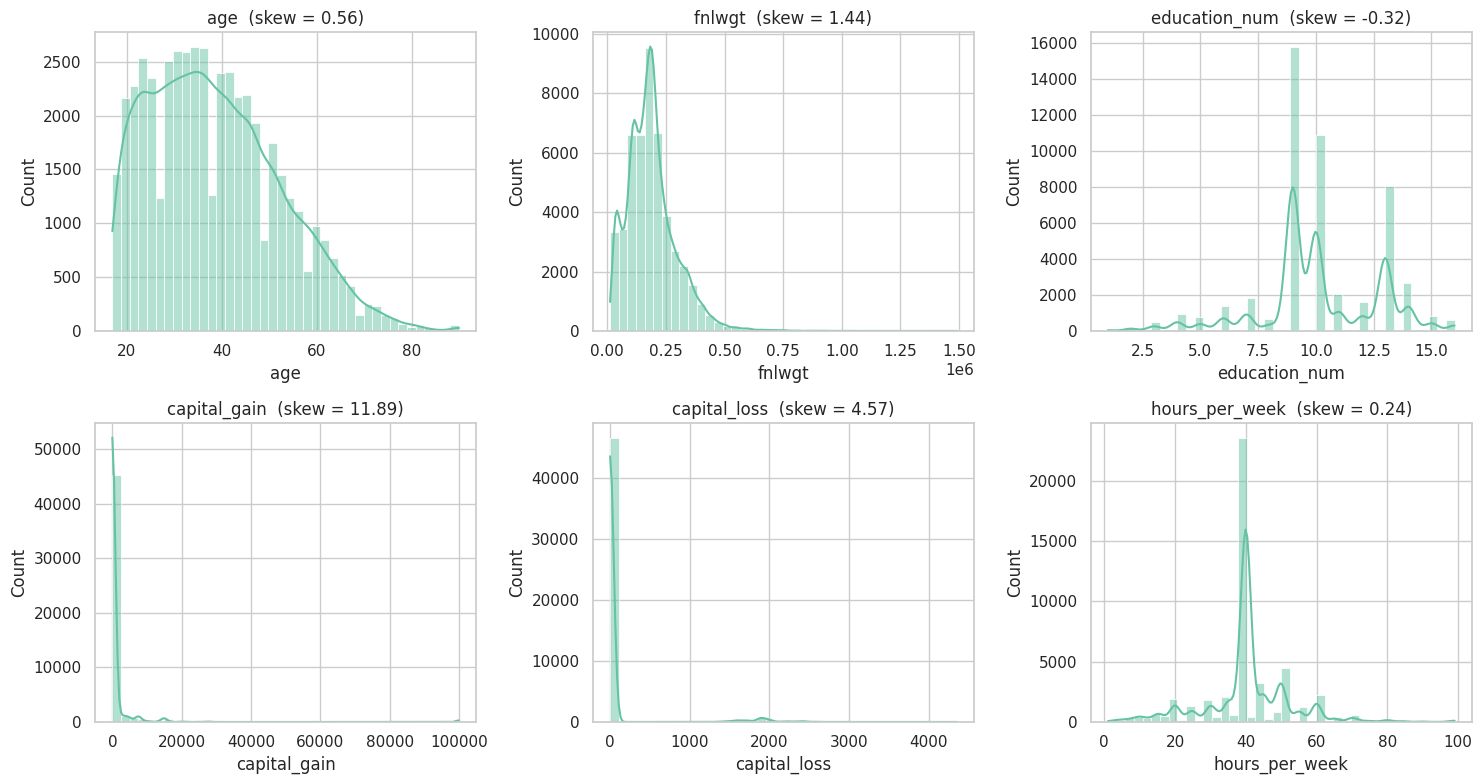

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_raw[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"{col}  (skew = {df_raw[col].skew():.2f})")
plt.tight_layout()
plt.show()

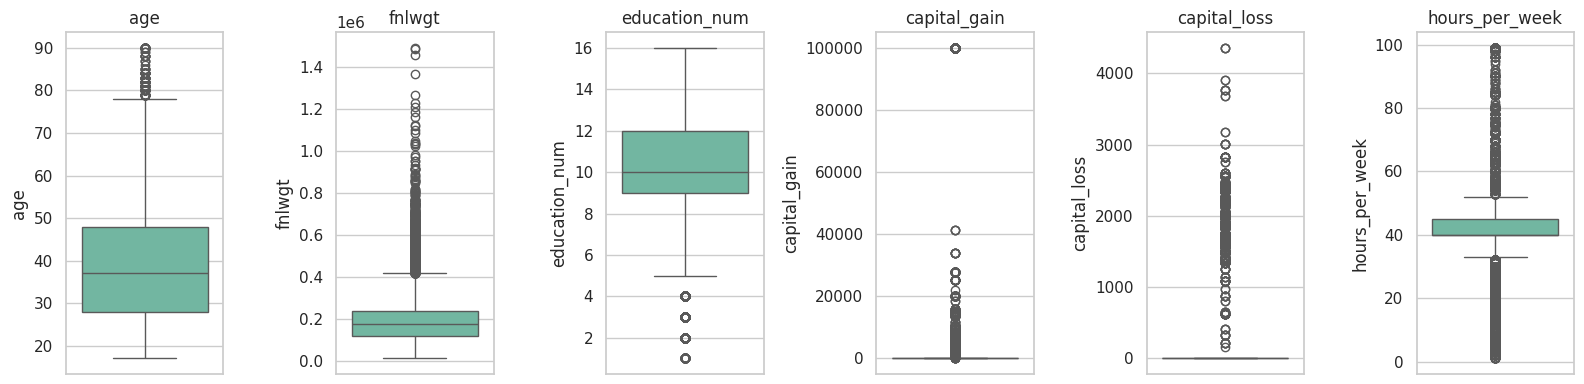

In [14]:
fig, axes = plt.subplots(1, 6, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_raw[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
# Part de zéros dans les variables de capital
for col in ["capital_gain", "capital_loss"]:
    print(f"{col} : {(df_raw[col] == 0).mean():.1%} de zéros")

capital_gain : 91.7% de zéros
capital_loss : 95.3% de zéros


**Observations**
- **`age`** : légèrement asymétrique à droite (beaucoup de 20-45 ans), pas d'anomalie hormis le pic à 90.
- **`hours_per_week`** : très concentré sur **40 h** (temps plein standard), avec des valeurs extrêmes
  dans les deux sens (1 h et 99 h). Les boxplots signalent beaucoup « d'outliers », mais ce sont des cas
  réels (temps partiel, cadres, indépendants) : on ne les supprimera pas.
- **`capital_gain` et `capital_loss`** : plus de 90 % de zéros et une très forte asymétrie. Ce ne sont pas
  des outliers à supprimer : les rares valeurs positives sont justement très informatives sur le revenu.
  Une transformation (log, ou indicateur binaire « possède du capital ») sera plus adaptée.
- **`fnlwgt`** : asymétrique, mais c'est un poids d'échantillonnage, pas une caractéristique de la personne.
- **`education_num`** : variable ordinale discrète (1 à 16), pics sur HS-grad (9), Some-college (10) et Bachelors (13).

### 3.4 Variables catégorielles : distributions

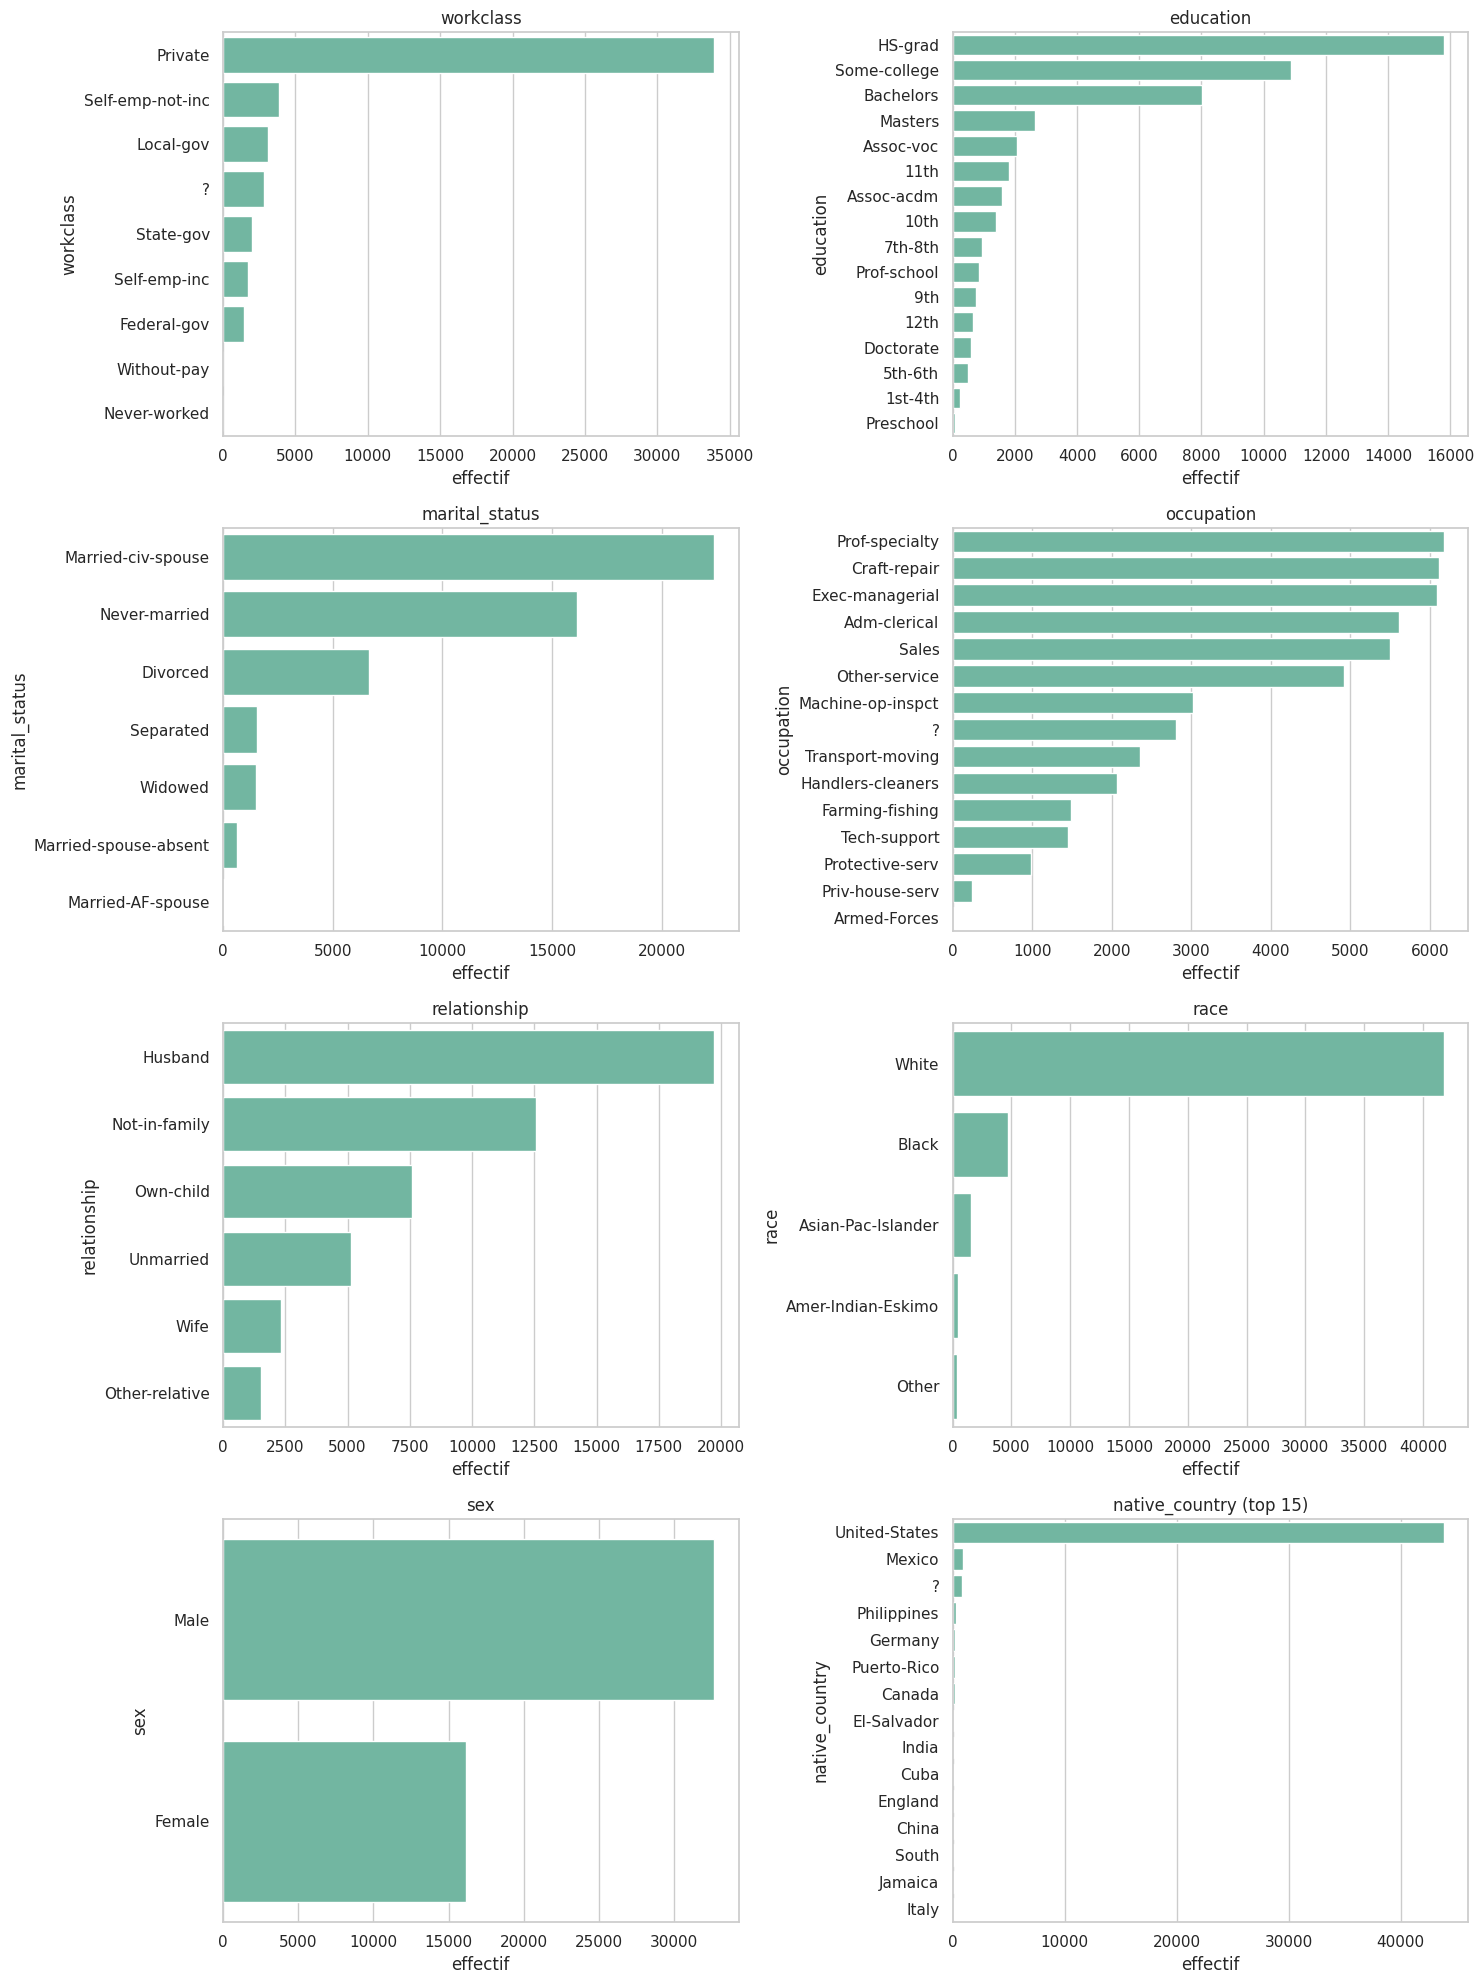

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
for ax, col in zip(axes.flat, cat_cols):
    order = df_raw[col].value_counts().index
    if col == "native_country":
        order = order[:15]  # les 15 pays les plus fréquents
    sns.countplot(data=df_raw, y=col, order=order, ax=ax)
    ax.set_title(col + (" (top 15)" if col == "native_country" else ""))
    ax.set_xlabel("effectif")
plt.tight_layout()
plt.show()

In [17]:
# Modalités rares (< 1 % des individus)
for col in cat_cols:
    freq = df_raw[col].value_counts(normalize=True)
    rares = freq[freq < 0.01]
    if len(rares):
        print(f"{col} : {len(rares)} modalité(s) rare(s) -> {list(rares.index[:8])}{' ...' if len(rares) > 8 else ''}")

workclass : 2 modalité(s) rare(s) -> ['Without-pay', 'Never-worked']
education : 2 modalité(s) rare(s) -> ['1st-4th', 'Preschool']
marital_status : 1 modalité(s) rare(s) -> ['Married-AF-spouse']
occupation : 2 modalité(s) rare(s) -> ['Priv-house-serv', 'Armed-Forces']
race : 2 modalité(s) rare(s) -> ['Amer-Indian-Eskimo', 'Other']
native_country : 39 modalité(s) rare(s) -> ['Philippines', 'Germany', 'Puerto-Rico', 'Canada', 'El-Salvador', 'India', 'Cuba', 'England'] ...


**Observations**
- **`workclass`** : le secteur privé domine (~70 %). Modalités très rares : `Without-pay`, `Never-worked`.
- **`native_country`** : environ 90 % des individus viennent des États-Unis, avec 40 autres pays souvent
  représentés par quelques dizaines de personnes. Un one-hot encoding brut créerait ~40 colonnes presque vides :
  il faudra **regrouper** (par ex. `United-States` / autres, ou par région du monde).
- **`education`** : 16 niveaux, dont plusieurs niveaux scolaires très proches (1st-4th, 5th-6th, …, 12th)
  qui pourront être regroupés.
- **`race`** et **`sex`** : population à ~85 % blanche et ~67 % masculine. Ces variables sensibles feront l'objet
  du test avec / sans (cf. Business Understanding).
- **`marital_status`** : `Married-AF-spouse` (conjoint militaire) est extrêmement rare.

### 3.5 Relations avec la cible

L'objectif est de repérer les variables les plus discriminantes pour le revenu, ce qui oriente à la fois
la classification et l'interprétation des futurs segments.

#### Variables numériques selon le revenu

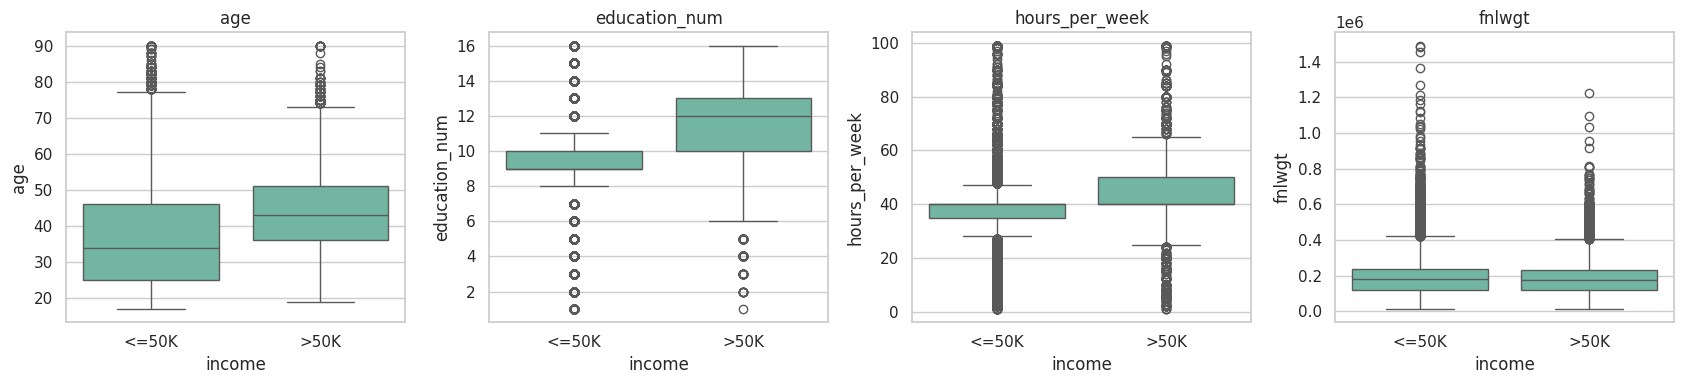

,age,education_num,hours_per_week,fnlwgt
income,,,,
<=50K,34.0,9.0,40.0,178811.0
>50K,43.0,12.0,40.0,176729.0


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes, ["age", "education_num", "hours_per_week", "fnlwgt"]):
    sns.boxplot(data=df_raw, x=target, y=col, ax=ax, order=["<=50K", ">50K"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

df_raw.groupby(target)[["age", "education_num", "hours_per_week", "fnlwgt"]].median()

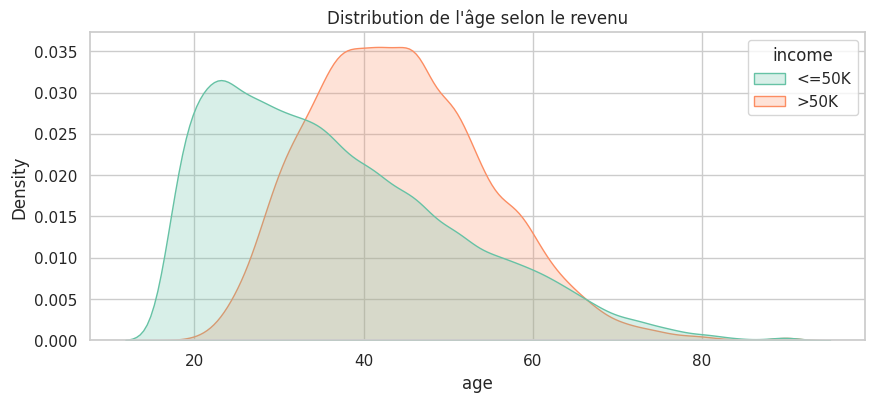

In [19]:
# Âge : distribution comparée
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_raw, x="age", hue=target, common_norm=False, fill=True)
plt.title("Distribution de l'âge selon le revenu")
plt.show()

In [20]:
# Posséder du capital change-t-il la probabilité de haut revenu ?
for col in ["capital_gain", "capital_loss"]:
    a = df_raw.loc[df_raw[col] > 0, "y"].mean()
    b = df_raw.loc[df_raw[col] == 0, "y"].mean()
    print(f"{col} > 0 : {a:.1%} de >50K   |   {col} = 0 : {b:.1%} de >50K")

capital_gain > 0 : 61.7% de >50K   |   capital_gain = 0 : 20.5% de >50K
capital_loss > 0 : 50.1% de >50K   |   capital_loss = 0 : 22.6% de >50K


**Observations**
- Les hauts revenus sont **plus âgés** (médiane ~43 ans contre ~34) et **plus diplômés**
  (médiane 12 contre 9). Les jeunes de moins de 25 ans sont presque tous `<=50K`.
- Ils travaillent **plus d'heures** en moyenne (la médiane est 40 h dans les deux cas, mais la distribution
  des `>50K` est décalée vers le haut).
- Posséder une plus-value multiplie fortement la probabilité de haut revenu (~60 % contre ~20 %) :
  l'indicateur binaire « a du capital » sera une variable utile.
- **`fnlwgt` a la même distribution dans les deux classes** : cela confirme qu'il n'apporte pas
  d'information prédictive et justifie son exclusion.

#### Variables catégorielles : taux de hauts revenus par modalité

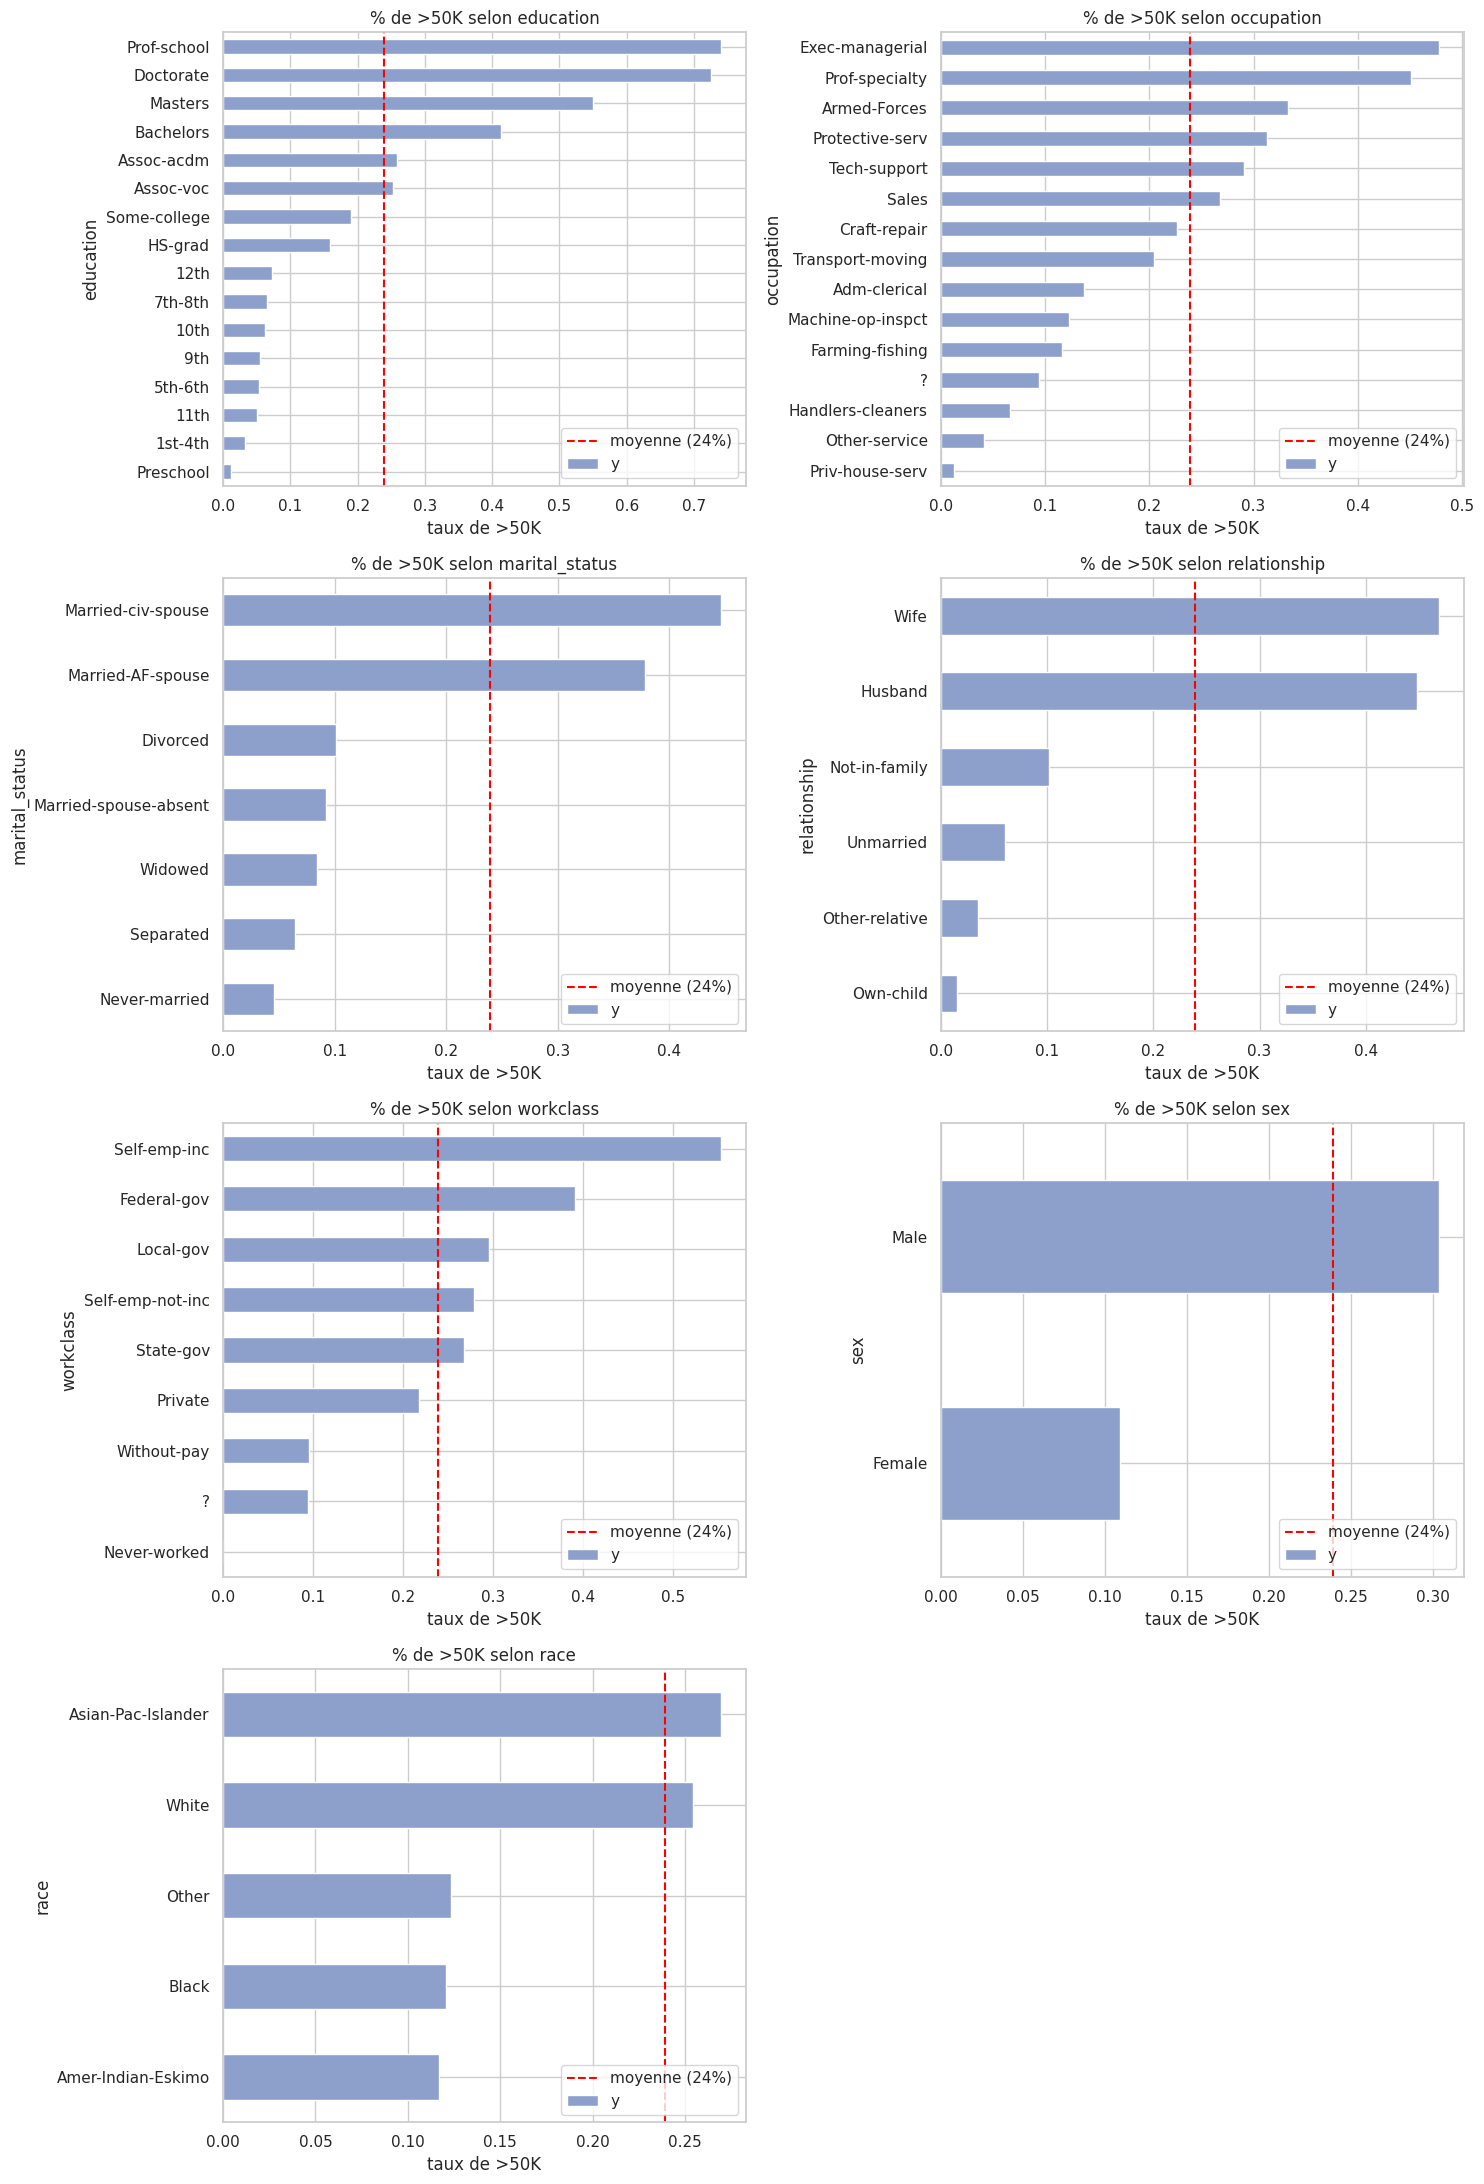

In [21]:
global_rate = df_raw["y"].mean()
plot_cols = ["education", "occupation", "marital_status", "relationship", "workclass", "sex", "race"]

fig, axes = plt.subplots(4, 2, figsize=(15, 22))
for ax, col in zip(axes.flat, plot_cols):
    rate = df_raw.groupby(col)["y"].mean().sort_values()
    rate.plot(kind="barh", ax=ax, color="#8da0cb")
    ax.axvline(global_rate, color="red", linestyle="--", label=f"moyenne ({global_rate:.0%})")
    ax.set_title(f"% de >50K selon {col}")
    ax.set_xlabel("taux de >50K")
    ax.legend(loc="lower right")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

**Observations**
- **`education`** : relation quasi monotone avec le revenu. Plus de 70 % de `>50K` pour Prof-school et
  Doctorate, contre moins de 10 % sous le niveau HS-grad. C'est l'une des variables les plus discriminantes.
- **`occupation`** : Exec-managerial et Prof-specialty dépassent 45 % de hauts revenus ; Other-service,
  Handlers-cleaners et Priv-house-serv sont sous 7 %.
- **`marital_status` / `relationship`** : les personnes mariées (Husband, Wife, Married-civ-spouse) ont
  ~45 % de hauts revenus, contre moins de 10 % pour les autres situations. Ce lien très fort s'explique
  en partie par l'âge et par le fait que le revenu déclaré peut être celui du foyer.
- **`workclass`** : les indépendants à leur compte en société (Self-emp-inc) et les fonctionnaires fédéraux
  sont les mieux rémunérés.
- **`sex`** et **`race`** : écarts importants (30 % de `>50K` chez les hommes contre 11 % chez les femmes).
  Ces écarts reflètent des inégalités sociales de 1994 ; les utiliser pour cibler des clients reproduirait
  ces inégalités, d'où le test avec / sans prévu dans la démarche.

### 3.6 Corrélations et redondances

#### Corrélations entre variables numériques

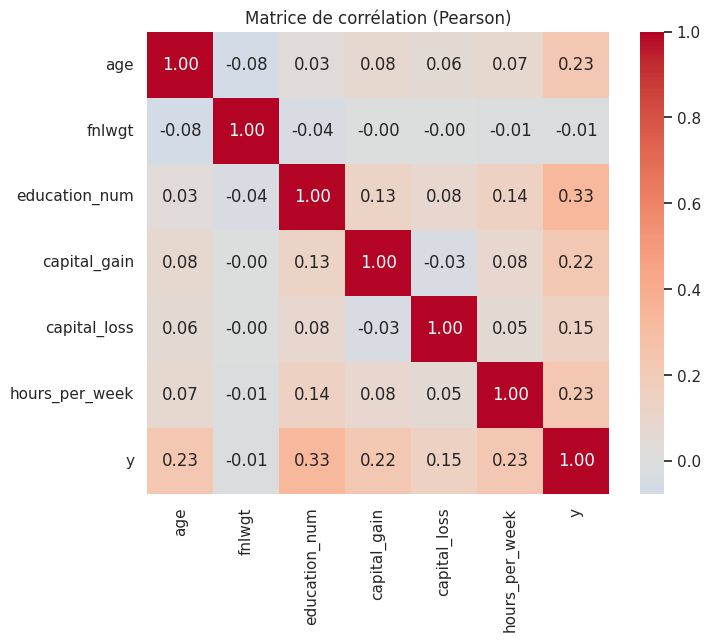

In [22]:
corr = df_raw[num_cols + ["y"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation (Pearson)")
plt.show()

**Observations**
- Les variables numériques sont **peu corrélées entre elles** (toutes < 0,15 en valeur absolue) :
  pas de problème de multicolinéarité.
- Corrélations avec la cible : `education_num` (0,33) est la plus forte, puis `age`, `hours_per_week`
  et `capital_gain` (~0,22). `fnlwgt` est à ~0 : confirmation de son inutilité.
- La corrélation de Pearson ne capte que les relations linéaires : par exemple l'effet de l'âge est
  plutôt en cloche (le revenu augmente puis baisse après 55-60 ans).

#### Redondance `education` / `education_num`

In [23]:
# Chaque niveau d'éducation correspond-il à un seul code ?
mapping = df_raw.groupby("education")["education_num"].agg(["nunique", "first"]).sort_values("first")
print("Nombre maximal de codes par diplôme :", mapping["nunique"].max())
mapping

Nombre maximal de codes par diplôme : 1


,nunique,first
education,,
Preschool,1,1
1st-4th,1,2
5th-6th,1,3
7th-8th,1,4
9th,1,5
10th,1,6
11th,1,7
12th,1,8
HS-grad,1,9


Chaque diplôme correspond exactement à un code : les deux variables contiennent **la même information**.
On en gardera une seule. `education_num` est préférable : elle est déjà ordonnée et numérique,
ce qui évite de créer 16 colonnes avec un one-hot encoding.

#### Redondance `relationship` / `marital_status`

In [24]:
pd.crosstab(df_raw["relationship"], df_raw["marital_status"])

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0,12,19704,0,0,0,0
Not-in-family,3628,0,23,330,7114,637,851
Other-relative,181,1,201,54,920,79,70
Own-child,455,1,143,61,6750,146,25
Unmarried,2369,0,0,183,1333,668,572
Wife,0,23,2308,0,0,0,0


`Husband` et `Wife` correspondent uniquement à des personnes mariées : les deux variables se recoupent
fortement. Par ailleurs `Husband`/`Wife` encode aussi le sexe, ce qui compte pour le test sans variables
sensibles. Une piste de feature engineering : une variable simplifiée `is_married` (marié / non marié).

#### Association entre variables catégorielles (V de Cramér)

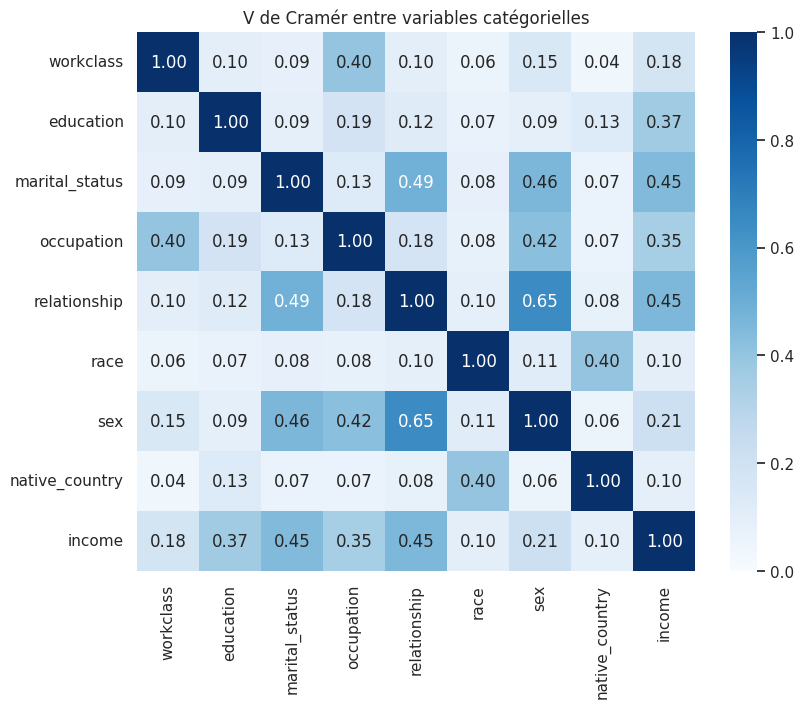

In [25]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cv_cols = cat_cols + [target]
cv = pd.DataFrame(index=cv_cols, columns=cv_cols, dtype=float)
for a in cv_cols:
    for b in cv_cols:
        cv.loc[a, b] = cramers_v(df_raw[a], df_raw[b])

plt.figure(figsize=(9, 7))
sns.heatmap(cv, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("V de Cramér entre variables catégorielles")
plt.show()

**Observations**
- `education` est parfaitement associée à `education_num` (vu plus haut) et `relationship` est très liée
  à `marital_status` et à `sex`.
- Avec la cible, les associations les plus fortes sont `relationship`, `marital_status`, `education`
  et `occupation`. Ce sont les variables à privilégier pour expliquer les hauts revenus.

### 3.7 Synthèse de l'exploration et plan de préparation

| Problème identifié | Variables concernées | Traitement envisagé (à justifier en partie 4) |
|---|---|---|
| Valeurs manquantes codées `?`, non aléatoires | `workclass`, `occupation`, `native_country` | modalité `Unknown` plutôt que le mode |
| Format différent du fichier test | `income` (point final), 1re ligne | corrigé au chargement |
| Doublons | toutes | suppression (impact négligeable) |
| Valeur plafond 99999 | `capital_gain` | conserver l'information, transformer (log / binaire) |
| Distributions très asymétriques, > 90 % de zéros | `capital_gain`, `capital_loss` | indicateur « a du capital », `log1p`, ou `capital_net` |
| Valeurs extrêmes mais réelles | `hours_per_week`, `age` | conserver ; éventuel plafonnement à discuter |
| Variable sans pouvoir prédictif | `fnlwgt` | exclusion des modèles |
| Redondance | `education` / `education_num` | garder `education_num` |
| Redondance partielle | `relationship` / `marital_status` | simplification (`is_married`) |
| Modalités rares / trop nombreuses | `native_country`, `workclass`, `education` | regroupement |
| Classes déséquilibrées (76 / 24) | `income` | métriques adaptées, `class_weight`, SMOTE |
| Variables sensibles | `sex`, `race` | comparaison des modèles avec / sans |
| Échelles très différentes | variables numériques | standardisation (indispensable pour K-Means) |

## 4. Data Preparation

Cette partie applique les traitements identifiés dans la synthèse de l'exploration (3.7).
Chaque choix est relié à l'objectif métier : **aider la banque à repérer les prospects à haut revenu
et à construire des segments de clientèle exploitables**.

**Principes suivis**
- On ne modifie jamais `df_raw` : le nettoyage se fait sur une copie `df_clean`.
- Le découpage officiel train / test (colonne `source`) est conservé jusqu'au bout.
- Les transformations qui « apprennent » quelque chose des données (moyenne et écart-type de la
  standardisation, modalités de l'encodage) sont **ajustées sur le train uniquement**, puis appliquées
  au test. Sinon, des informations du test fuiraient dans le modèle et ses performances seraient surestimées.

**Deux fichiers sont produits**
- `adult_clean.csv` : données nettoyées et enrichies, encore lisibles (utile pour interpréter les segments) ;
- `adult_prepared.csv` : données encodées et standardisées, prêtes pour le clustering et la classification
  (c'est le livrable « données préparées »).

### 4.1 Nettoyage

#### Étape 1 : copie de travail

In [26]:
# On travaille sur une copie : df_raw reste intact si on veut revenir en arrière.
# On retire "y", la colonne 0/1 temporaire créée pour l'exploration.
df_clean = df_raw.drop(columns="y").copy()
n_initial = len(df_clean)   # pour compter à la fin combien de lignes ont été supprimées
print("Lignes au départ :", n_initial)

Lignes au départ : 48842


#### Étape 2 : suppression des doublons

In [27]:
# duplicated() renvoie True pour chaque ligne déjà vue plus haut (on garde la 1re occurrence)
dup_mask = df_clean.duplicated(subset=COLUMNS, keep="first")
print("Doublons supprimés :", dup_mask.sum())
print("dont lignes du test identiques à une ligne du train :",
      (dup_mask & (df_clean["source"] == "test")
       & df_clean[COLUMNS].apply(tuple, axis=1).isin(
           df_clean.loc[df_clean["source"] == "train", COLUMNS].apply(tuple, axis=1))).sum())

# ~ signifie "NON" : on garde les lignes qui ne sont PAS des doublons
df_clean = df_clean[~dup_mask].reset_index(drop=True)
print("Lignes restantes :", len(df_clean))

Doublons supprimés : 52


dont lignes du test identiques à une ligne du train : 23
Lignes restantes : 48790


**Pourquoi supprimer ?** Les lignes sont identiques sur toutes les variables, y compris `fnlwgt` qui est
presque unique pour chaque personne : ce sont très probablement des enregistrements en double.
Leur suppression a un impact négligeable (~0,1 % des lignes) mais évite deux problèmes :
- une personne comptée deux fois pèse deux fois plus dans le modèle et dans les segments ;
- une ligne du test identique à une ligne du train ferait paraître le modèle meilleur qu'il n'est (fuite de données).

#### Étape 3 : incohérences logiques

In [28]:
# Une ligne est incohérente si le rôle dans le foyer contredit le sexe
incoherent = (
    ((df_clean["relationship"] == "Husband") & (df_clean["sex"] == "Female")) |
    ((df_clean["relationship"] == "Wife") & (df_clean["sex"] == "Male"))
)
print("Lignes incohérentes (Husband femme / Wife homme) :", incoherent.sum())
display(df_clean.loc[incoherent, ["age", "marital_status", "relationship", "sex", "income"]])

df_clean = df_clean[~incoherent].reset_index(drop=True)

# Autres contrôles de cohérence : tous doivent afficher 0
print("Âge < 17 ou > 90           :", ((df_clean["age"] < 17) | (df_clean["age"] > 90)).sum())
print("Heures <= 0 ou > 99        :", ((df_clean["hours_per_week"] <= 0) | (df_clean["hours_per_week"] > 99)).sum())
print("Capital négatif            :", ((df_clean["capital_gain"] < 0) | (df_clean["capital_loss"] < 0)).sum())

Lignes incohérentes (Husband femme / Wife homme) : 4


,age,marital_status,relationship,sex,income
575,29,Married-civ-spouse,Wife,Male,>50K
7107,34,Married-civ-spouse,Husband,Female,<=50K
27124,36,Married-civ-spouse,Wife,Male,<=50K
38192,64,Married-civ-spouse,Wife,Male,<=50K


Âge < 17 ou > 90           : 0
Heures <= 0 ou > 99        : 0
Capital négatif            : 0


Un « mari » de sexe féminin ou une « épouse » de sexe masculin est une contradiction : l'une des deux
valeurs est une erreur de saisie, mais on ne peut pas savoir laquelle. Corriger reviendrait à deviner.
Comme ces cas sont très rares (4 lignes), on les **supprime**, sans effet sur le reste des données.
Les autres contrôles (bornes de l'âge, des heures, du capital) ne révèlent aucun problème.

#### Étape 4 : valeurs manquantes

**Rappel de l'exploration** : les `?` de `workclass` et `occupation` concernent les mêmes personnes,
sur-représentées chez les moins de 25 ans et les plus de 60 ans, avec un taux de hauts revenus de
~9 % contre ~24 % en moyenne. Les valeurs ne manquent donc **pas au hasard** : le fait même qu'elles
manquent est une information (probablement étudiants, retraités ou personnes sans emploi).

**Comparaison des méthodes possibles**

| Méthode | Avantage | Inconvénient dans notre cas |
|---|---|---|
| Supprimer les lignes | simple | perte de ~7 % des données, et surtout perte ciblée des jeunes et des seniors, deux publics importants pour une banque |
| Imputer par le mode (`Private`, `Prof-specialty`) | conserve les lignes | invente un emploi, et même un métier très bien payé, à des personnes qui n'en ont probablement pas : biais vers le haut revenu |
| Imputer par un modèle (KNN…) | plus fin que le mode | plus coûteux, et invente quand même une valeur ; efface le signal « inconnu » |
| **Créer une modalité `Unknown`** ✅ | conserve les lignes **et** l'information que la valeur manque | ajoute une modalité de plus (sans gravité) |

**Choix retenu : modalité `Unknown`** pour `workclass`, `occupation` et `native_country`.
Cas particulier : les 10 personnes `Never-worked` n'ont pas de métier ; ce n'est pas une donnée manquante
mais une absence logique, codée `None`.

In [29]:
# Cas logique : jamais travaillé -> pas de métier
never = df_clean["workclass"] == "Never-worked"
df_clean.loc[never & (df_clean["occupation"] == "?"), "occupation"] = "None"

# Modalité "Unknown" pour les vraies valeurs manquantes
for col in ["workclass", "occupation", "native_country"]:
    df_clean[col] = df_clean[col].replace("?", "Unknown")

# Vérification : plus aucun "?" ni NaN
print("Valeurs '?' restantes :", (df_clean == "?").sum().sum())
print("NaN restants          :", df_clean.isna().sum().sum())

Valeurs '?' restantes : 0
NaN restants          : 0


In [30]:
# Le taux de hauts revenus de la modalité Unknown confirme qu'elle porte une information
y_tmp = (df_clean["income"] == ">50K")
(y_tmp.groupby(df_clean["workclass"]).mean().sort_values(ascending=False) * 100).round(1).rename("% >50K")

workclass
Self-emp-inc        55.4
Federal-gov         39.2
Local-gov           29.6
Self-emp-not-inc    27.9
State-gov           26.8
Private             21.8
Without-pay          9.5
Unknown              9.5
Never-worked         0.0
Name: % >50K, dtype: float64

#### Étape 5 : valeurs aberrantes (outliers)

On commence par la méthode classique de l'écart interquartile (IQR) : une valeur est signalée si elle est
en dehors de [Q1 − 1,5 × IQR ; Q3 + 1,5 × IQR].

In [31]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

out = pd.DataFrame({
    "nb_outliers_IQR": [iqr_outliers(df_clean[c]) for c in num_cols],
}, index=num_cols)
out["%"] = (out["nb_outliers_IQR"] / len(df_clean) * 100).round(1)
out

,nb_outliers_IQR,%
age,215,0.4
fnlwgt,1453,3.0
education_num,1787,3.7
capital_gain,4035,8.3
capital_loss,2282,4.7
hours_per_week,13485,27.6


La méthode IQR signale **plus d'un quart des individus** pour `hours_per_week` et toutes les personnes
ayant du capital. Elle n'est **pas adaptée** ici : elle suppose une distribution à peu près symétrique,
alors que `hours_per_week` est concentrée sur 40 h et que `capital_gain` est nulle à plus de 90 %.
Toute valeur différente de la norme devient alors un « outlier ».

Il faut donc distinguer les **erreurs** (à corriger) des **valeurs extrêmes réelles** (à garder) :

In [32]:
# Les valeurs extrêmes sont-elles liées au revenu ? Si oui, elles sont informatives.
regime = pd.cut(df_clean["hours_per_week"], [0, 34, 45, 99],
                labels=["< 35 h", "35-45 h", "> 45 h"])
print("% de >50K selon le temps de travail :")
print((y_tmp.groupby(regime, observed=True).mean() * 100).round(1))

print("\n% de >50K parmi capital_gain = 99999 :",
      round(y_tmp[df_clean["capital_gain"] == 99999].mean() * 100, 1))

% de >50K selon le temps de travail :
hours_per_week
< 35 h      6.9
35-45 h    22.4
> 45 h     41.6
Name: income, dtype: float64

% de >50K parmi capital_gain = 99999 : 100.0


| Variable | Constat | Décision | Justification |
|---|---|---|---|
| `age` | 17 à 90 ans, pic à 90 | **conserver** | âges réalistes ; 90 = « 90 ans et plus » |
| `hours_per_week` | 1 h à 99 h | **conserver** | temps partiel et longues journées existent ; plus d'heures = plus de hauts revenus (information utile) |
| `capital_gain` | 99 999 = valeur plafond | **conserver**, réduire l'échelle par log (4.2) | 100 % de ces personnes sont `>50K` : les supprimer reviendrait à retirer les meilleurs prospects de la banque |
| `capital_loss` | très asymétrique | **conserver**, log (4.2) | même raisonnement |
| `fnlwgt` | asymétrique | sans objet | variable supprimée à l'étape suivante |

**Aucune ligne n'est supprimée pour outlier.** Le vrai problème de ces variables n'est pas la présence
d'erreurs, mais leur **échelle très étirée**, qui gênerait les algorithmes basés sur les distances
(K-Means) et la régression logistique. Il est traité par transformation (log + standardisation),
ce qui réduit l'influence des valeurs extrêmes sans perdre d'information.

#### Étape 6 : suppression des variables inutiles ou redondantes

In [33]:
# axis colonnes : on retire les deux variables jugées inutiles / redondantes
df_clean = df_clean.drop(columns=["fnlwgt", "education"])
print("Colonnes restantes :", list(df_clean.columns))

Colonnes restantes : ['age', 'workclass', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'source']


- **`fnlwgt`** : poids d'échantillonnage du recensement, pas une caractéristique du client.
  L'exploration a montré la même distribution dans les deux classes (corrélation ≈ 0 avec la cible).
  Une banque ne disposerait d'ailleurs jamais de cette information sur ses prospects.
- **`education`** : contient exactement la même information que `education_num` (correspondance 1 pour 1).
  On garde `education_num`, déjà numérique et ordonnée : un one-hot de `education` aurait créé
  16 colonnes et perdu l'ordre naturel des diplômes.

#### Étape 7 : encodage de la variable cible

In [34]:
# True/False -> 1/0 : 1 = revenu > 50K = prospect cible de la banque
df_clean["income_high"] = (df_clean["income"] == ">50K").astype(int)
df_clean = df_clean.drop(columns="income")
print(df_clean["income_high"].value_counts())
print("\nLignes supprimées au total pendant le nettoyage :", n_initial - len(df_clean),
      f"({(n_initial - len(df_clean)) / n_initial:.2%})")

income_high
0    37106
1    11680
Name: count, dtype: int64

Lignes supprimées au total pendant le nettoyage : 56 (0.11%)


`income_high` vaut **1** pour un revenu `>50K` (prospect cible de la banque) et **0** sinon.
Le déséquilibre des classes (~24 % de 1) n'est **pas corrigé dans le fichier** : un rééquilibrage
(SMOTE, sous-échantillonnage…) doit se faire uniquement sur le train, au moment de la modélisation,
pour que le test reste représentatif de la population réelle.

### 4.2 Transformation et feature engineering

#### a) Regroupement de modalités

Trop de modalités, ou des modalités très rares, posent deux problèmes : un one-hot encoding crée
des colonnes presque vides (bruit, risque de surapprentissage), et les segments deviennent difficiles
à décrire. On regroupe donc des modalités **proches par leur sens et par leur taux de hauts revenus**.

In [35]:
def rate_table(col):
    # taux de >50K et effectif par modalité, pour justifier les regroupements
    g = df_clean.groupby(col)["income_high"].agg(["mean", "size"])
    g["mean"] = (g["mean"] * 100).round(1)
    return g.rename(columns={"mean": "% >50K", "size": "effectif"}).sort_values("% >50K", ascending=False)

rate_table("workclass")

,% >50K,effectif
workclass,,
Self-emp-inc,55.4,1694
Federal-gov,39.2,1432
Local-gov,29.6,3135
Self-emp-not-inc,27.9,3861
State-gov,26.8,1981
Private,21.8,33857
Unknown,9.5,2795
Without-pay,9.5,21
Never-worked,0.0,10


In [36]:
workclass_map = {
    "Private": "Private",
    "Self-emp-not-inc": "Self-emp-not-inc",
    "Self-emp-inc": "Self-emp-inc",
    "Federal-gov": "Federal-gov",
    "State-gov": "State-Local-gov",
    "Local-gov": "State-Local-gov",
    "Without-pay": "No-income",
    "Never-worked": "No-income",
    "Unknown": "Unknown",
}
# map() remplace chaque modalité par son groupe défini dans le dictionnaire
df_clean["workclass"] = df_clean["workclass"].map(workclass_map)
rate_table("workclass")

,% >50K,effectif
workclass,,
Self-emp-inc,55.4,1694
Federal-gov,39.2,1432
State-Local-gov,28.5,5116
Self-emp-not-inc,27.9,3861
Private,21.8,33857
Unknown,9.5,2795
No-income,6.5,31


- `State-gov` et `Local-gov` : deux administrations au fonctionnement proche et aux taux similaires (~27-30 %).
- `Without-pay` et `Never-worked` : seulement ~30 personnes, toutes deux sans revenu du travail.
- On garde séparés `Self-emp-inc` (chefs d'entreprise, ~55 % de hauts revenus) et `Self-emp-not-inc`
  (indépendants, ~28 %) : leurs profils sont très différents, et ce sont deux cibles distinctes pour une
  banque (offres professionnelles).
- On garde `Federal-gov` à part : son taux (~39 %) est nettement plus élevé que les autres administrations.

In [37]:
rate_table("occupation")

,% >50K,effectif
occupation,,
Exec-managerial,47.8,6081
Prof-specialty,45.1,6165
Armed-Forces,33.3,15
Protective-serv,31.4,982
Tech-support,29.1,1445
Sales,26.8,5499
Craft-repair,22.6,6102
Transport-moving,20.4,2355
Adm-clerical,13.7,5606


In [38]:
# Armed-Forces (~15 personnes) rejoint le métier le plus proche par nature et par taux
df_clean["occupation"] = df_clean["occupation"].replace({"Armed-Forces": "Protective-serv"})
# None (10 personnes sans emploi) rejoint Unknown : effectif trop faible pour une catégorie seule
df_clean["occupation"] = df_clean["occupation"].replace({"None": "Unknown"})
print(df_clean["occupation"].nunique(), "métiers")

14 métiers


In [39]:
marital_map = {
    "Married-civ-spouse": "Married",
    "Married-AF-spouse": "Married",
    "Never-married": "Never-married",
    "Divorced": "Divorced-Separated",
    "Separated": "Divorced-Separated",
    "Married-spouse-absent": "Divorced-Separated",
    "Widowed": "Widowed",
}
print(rate_table("marital_status"))
df_clean["marital_status"] = df_clean["marital_status"].map(marital_map)
rate_table("marital_status")

                       % >50K  effectif
marital_status                         
Married-civ-spouse       44.6     22362
Married-AF-spouse        37.8        37
Divorced                 10.1      6630
Married-spouse-absent     9.3       627
Widowed                   8.4      1518
Separated                 6.5      1530
Never-married             4.6     16082


,% >50K,effectif
marital_status,,
Married,44.6,22399
Divorced-Separated,9.4,8787
Widowed,8.4,1518
Never-married,4.6,16082


- `Married-AF-spouse` (conjoint militaire, ~35 personnes) est un mariage comme les autres.
- `Divorced`, `Separated` et `Married-spouse-absent` décrivent une personne qui vit sans conjoint après
  une union, avec des taux de hauts revenus proches (6 à 10 %).

In [40]:
region_map = {
    "United-States": "United-States",
    # Amérique latine et Caraïbes
    "Mexico": "Latin-America", "Puerto-Rico": "Latin-America", "El-Salvador": "Latin-America",
    "Cuba": "Latin-America", "Jamaica": "Latin-America", "Dominican-Republic": "Latin-America",
    "Guatemala": "Latin-America", "Columbia": "Latin-America", "Haiti": "Latin-America",
    "Nicaragua": "Latin-America", "Peru": "Latin-America", "Ecuador": "Latin-America",
    "Trinadad&Tobago": "Latin-America", "Honduras": "Latin-America",
    # Asie
    "Philippines": "Asia", "India": "Asia", "China": "Asia", "Japan": "Asia", "Vietnam": "Asia",
    "Taiwan": "Asia", "Iran": "Asia", "Thailand": "Asia", "Hong": "Asia", "Cambodia": "Asia",
    "Laos": "Asia",
    # Europe et Canada
    "Germany": "Europe-Canada", "Canada": "Europe-Canada", "England": "Europe-Canada",
    "Italy": "Europe-Canada", "Poland": "Europe-Canada", "Portugal": "Europe-Canada",
    "Greece": "Europe-Canada", "France": "Europe-Canada", "Ireland": "Europe-Canada",
    "Yugoslavia": "Europe-Canada", "Scotland": "Europe-Canada", "Hungary": "Europe-Canada",
    "Holand-Netherlands": "Europe-Canada",
    # Ambigus ou trop rares
    "South": "Other", "Outlying-US(Guam-USVI-etc)": "Other",
    "Unknown": "Unknown",
}
df_clean["native_region"] = df_clean["native_country"].map(region_map)
assert df_clean["native_region"].notna().all(), "un pays n'a pas été classé"
df_clean = df_clean.drop(columns="native_country")
rate_table("native_region")

,% >50K,effectif
native_region,,
Europe-Canada,30.5,962
Asia,30.0,980
Unknown,25.8,854
United-States,24.4,43790
Other,15.2,138
Latin-America,8.0,2062


`native_country` comptait 41 pays, dont la plupart avec moins de 1 % des individus. Un one-hot aurait créé
~40 colonnes presque vides. On regroupe par **grande région**, ce qui garde une information utile
(les taux de hauts revenus diffèrent nettement entre régions) en 6 modalités seulement.
`South` est ambigu (Corée du Sud ? Afrique du Sud ?) et rejoint `Other` avec les territoires américains.

#### b) Création de nouvelles variables (feature engineering)

Chaque nouvelle variable répond à un besoin de la banque ou corrige un problème vu en exploration.

In [41]:
# 1. Possession de capital : indicateur simple et très discriminant (~60 % de >50K contre ~20 %)
df_clean["has_capital"] = ((df_clean["capital_gain"] > 0) | (df_clean["capital_loss"] > 0)).astype(int)

# 2. Capital net : personne n'a à la fois une plus-value et une moins-value,
#    on peut donc résumer les deux colonnes en une seule mesure du patrimoine financier
df_clean["capital_net"] = df_clean["capital_gain"] - df_clean["capital_loss"]

# 3. Version log des montants : réduit l'asymétrie extrême (voir c)
df_clean["log_capital_gain"] = np.log1p(df_clean["capital_gain"])
df_clean["log_capital_loss"] = np.log1p(df_clean["capital_loss"])

# 4. Statut marié : version binaire simple de marital_status
df_clean["is_married"] = (df_clean["marital_status"] == "Married").astype(int)

# 5. Tranches d'âge : vocabulaire habituel du marketing bancaire
df_clean["age_group"] = pd.cut(df_clean["age"], [16, 25, 35, 45, 55, 65, 90],
                               labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"])

# 6. Régime de travail
df_clean["work_regime"] = pd.cut(df_clean["hours_per_week"], [0, 34, 45, 99],
                                 labels=["Part-time", "Full-time", "Overtime"])

# 7. Niveau d'éducation simplifié (lisible pour décrire les segments)
df_clean["education_level"] = pd.cut(df_clean["education_num"], [0, 8, 9, 12, 13, 16],
                                     labels=["No-HS-diploma", "HS-grad", "Some-college-Assoc",
                                             "Bachelors", "Postgraduate"])
df_clean.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,source,income_high,native_region,has_capital,capital_net,log_capital_gain,log_capital_loss,is_married,age_group,work_regime,education_level
0,39,State-Local-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,train,0,United-States,1,2174,7.684784,0.0,0,36-45,Full-time,Bachelors
1,50,Self-emp-not-inc,13,Married,Exec-managerial,Husband,White,Male,0,0,13,train,0,United-States,0,0,0.000000,0.0,1,46-55,Part-time,Bachelors
2,38,Private,9,Divorced-Separated,Handlers-cleaners,Not-in-family,White,Male,0,0,40,train,0,United-States,0,0,0.000000,0.0,0,36-45,Full-time,HS-grad
3,53,Private,7,Married,Handlers-cleaners,Husband,Black,Male,0,0,40,train,0,United-States,0,0,0.000000,0.0,1,46-55,Full-time,No-HS-diploma
4,28,Private,13,Married,Prof-specialty,Wife,Black,Female,0,0,40,train,0,Latin-America,0,0,0.000000,0.0,1,26-35,Full-time,Bachelors


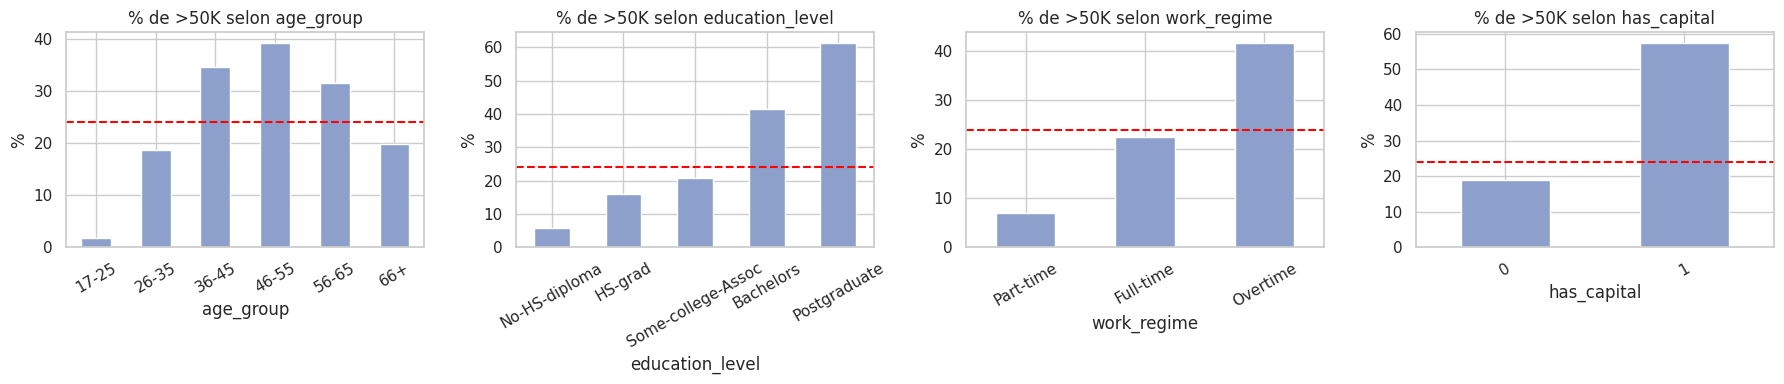

In [42]:
# Vérification : les nouvelles variables discriminent-elles bien les hauts revenus ?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["age_group", "education_level", "work_regime", "has_capital"]):
    (df_clean.groupby(col, observed=True)["income_high"].mean() * 100).plot(kind="bar", ax=ax, color="#8da0cb")
    ax.axhline(df_clean["income_high"].mean() * 100, color="red", linestyle="--")
    ax.set_title(f"% de >50K selon {col}")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Rôle des nouvelles variables**

| Variable | Pourquoi | Usage |
|---|---|---|
| `has_capital` | une personne qui a du capital a ~3 fois plus de chances d'être `>50K` ; c'est aussi un client naturel pour les placements | modèles + segments |
| `capital_net` | résume plus-values et moins-values en une mesure du patrimoine | interprétation |
| `log_capital_gain`, `log_capital_loss` | réduisent l'asymétrie (voir ci-dessous) | modèles |
| `is_married` | statut le plus lié au revenu (~45 % de `>50K` chez les mariés) | interprétation des segments |
| `age_group`, `work_regime`, `education_level` | tranches lisibles pour décrire les segments en langage métier | interprétation des segments |

Les tranches (`age_group`, `work_regime`, `education_level`) **ne sont pas données aux modèles** :
elles répètent l'information des variables numériques d'origine en la dégradant. Elles servent à
décrire les clusters (« segment des 36-45 ans diplômés du supérieur… »).
On voit aussi que la relation âge / revenu est **en cloche** (pic vers 46-55 ans), ce qu'un modèle
linéaire captera mal : à garder en tête pour la classification.

#### c) Transformation des distributions

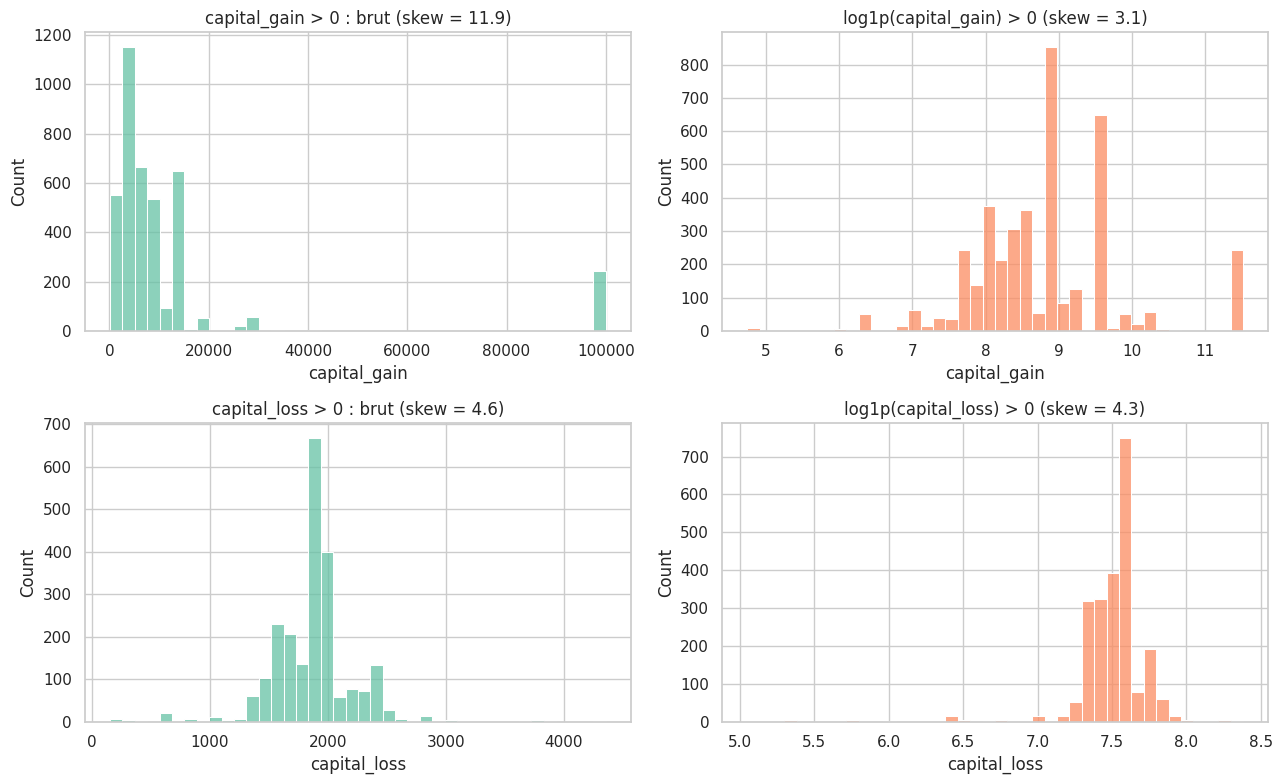

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(["capital_gain", "capital_loss"]):
    pos = df_clean.loc[df_clean[col] > 0, col]  # on montre les valeurs non nulles
    sns.histplot(pos, bins=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} > 0 : brut (skew = {df_clean[col].skew():.1f})")
    sns.histplot(np.log1p(pos), bins=40, ax=axes[i, 1], color="#fc8d62")
    axes[i, 1].set_title(f"log1p({col}) > 0 (skew = {df_clean['log_' + col].skew():.1f})")
plt.tight_layout()
plt.show()

**Pourquoi `log1p` ?** Les montants de capital vont de 0 à 99 999 avec une poignée de très grandes valeurs.
Sans transformation, ces quelques valeurs écraseraient toutes les autres dans le calcul des distances
(K-Means) et des coefficients (régression logistique). Le logarithme compresse les grandes valeurs tout en
gardant l'ordre : 99 999 devient ~11,5 au lieu de dominer l'échelle.
On utilise `log1p(x) = log(1 + x)` plutôt que `log(x)` car `log(0)` n'existe pas, alors que plus de 90 %
des valeurs sont nulles (`log1p(0) = 0`).

L'asymétrie reste élevée à cause de la masse de zéros, qu'aucune transformation ne peut faire disparaître :
c'est pourquoi on ajoute l'indicateur `has_capital`, qui porte l'information « possède / ne possède pas ».

Les autres variables numériques (`age`, `education_num`, `hours_per_week`) ont une asymétrie modérée :
une transformation n'est pas nécessaire, la standardisation suffit.

#### d) Export des données nettoyées (version lisible)

In [44]:
df_clean.to_csv("adult_clean.csv", index=False)
print("adult_clean.csv :", df_clean.shape)
df_clean.dtypes

adult_clean.csv : (48786, 22)


age                    int64
workclass                str
education_num          int64
marital_status           str
occupation               str
relationship             str
race                     str
sex                      str
capital_gain           int64
capital_loss           int64
hours_per_week         int64
source                   str
income_high            int64
native_region            str
has_capital            int64
capital_net            int64
log_capital_gain     float64
log_capital_loss     float64
is_married             int64
age_group           category
work_regime         category
education_level     category
dtype: object

### 4.3 Encodage et mise à l'échelle

#### Choix des variables pour la modélisation

In [45]:
num_features = ["age", "education_num", "hours_per_week", "log_capital_gain", "log_capital_loss"]
bin_features = ["has_capital"]
cat_features = ["workclass", "occupation", "marital_status", "relationship",
                "native_region", "race", "sex"]
sensitive = ["sex", "race", "relationship", "native_region"]  # à retirer pour le modèle "sans variables sensibles"

print("Numériques :", num_features)
print("Binaires   :", bin_features)
print("Nominales  :", cat_features)

Numériques : ['age', 'education_num', 'hours_per_week', 'log_capital_gain', 'log_capital_loss']
Binaires   : ['has_capital']
Nominales  : ['workclass', 'occupation', 'marital_status', 'relationship', 'native_region', 'race', 'sex']


- `relationship` est classée parmi les variables sensibles car ses modalités `Husband` / `Wife`
  révèlent le sexe : retirer `sex` sans retirer `relationship` ne supprimerait pas vraiment l'information.
- `native_region` (origine géographique) est aussi sensible : la discrimination selon l'origine nationale
  est interdite au même titre que celle fondée sur le sexe ou l'origine ethnique.
- `capital_gain` / `capital_loss` brutes sont remplacées par leur version log ; `capital_net` et les tranches
  servent à l'interprétation.

#### Encodage des variables catégorielles

| Méthode | Principe | Adaptée ici ? |
|---|---|---|
| Label encoding (0, 1, 2…) | un numéro par modalité | ❌ crée un ordre artificiel (« Sales » > « Craft-repair » ?) que K-Means et la régression logistique interpréteraient comme une distance |
| Ordinal encoding | numéros dans un ordre logique | seulement pour les variables ordonnées : c'est déjà le cas de `education_num` |
| Target encoding | remplace la modalité par le taux de `>50K` | ❌ utilise la cible : risque de fuite de données, et inutilisable tel quel pour le clustering |
| **One-hot encoding** ✅ | une colonne 0/1 par modalité | ✅ aucune hypothèse d'ordre ; nombre de colonnes raisonnable grâce aux regroupements |

`sex`, qui n'a que deux modalités, devient une seule colonne 0/1 (`drop="if_binary"`).
`handle_unknown="ignore"` évite une erreur si une modalité apparaissait dans le test sans être dans le train.

#### Mise à l'échelle des variables numériques

Les variables ont des échelles très différentes (`age` jusqu'à 90, `education_num` jusqu'à 16,
`log_capital_gain` jusqu'à ~11,5). Sans mise à l'échelle, K-Means donnerait plus de poids aux variables
aux grandes valeurs, et la régression logistique convergerait mal.

- **StandardScaler** ✅ (moyenne 0, écart-type 1) : standard pour K-Means et la régression logistique.
- MinMaxScaler (entre 0 et 1) : écarté, car très sensible aux valeurs extrêmes : avec les longues heures
  ou l'âge de 90 ans, la plupart des individus seraient tassés dans un petit intervalle.
- Les colonnes 0/1 (one-hot et binaires) ne sont pas standardisées : elles sont déjà sur une échelle comparable.

Le scaler et l'encodeur sont **ajustés sur le train uniquement** (`fit`), puis appliqués au train et au test (`transform`).

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Le ColumnTransformer applique un traitement différent à chaque groupe de colonnes :
#  - "num" : standardisation (moyenne 0, écart-type 1)
#  - "cat" : one-hot encoding (une colonne 0/1 par modalité)
#  - "bin" : déjà en 0/1, on les laisse telles quelles ("passthrough")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat_features),
        ("bin", "passthrough", bin_features),
    ]
)

is_train = df_clean["source"] == "train"
preprocessor.fit(df_clean.loc[is_train])          # apprentissage sur le train seulement

X_all = preprocessor.transform(df_clean)          # application à tout le dataset

# Noms lisibles des nouvelles colonnes (ex. "cat__occupation_Sales" -> "occupation_Sales")
feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]

# On remet le résultat dans un DataFrame et on rajoute la cible et la source,
# qui ne doivent pas être transformées
df_prep = pd.DataFrame(X_all, columns=feature_names, index=df_clean.index)
df_prep["income_high"] = df_clean["income_high"].values
df_prep["source"] = df_clean["source"].values

print("Forme finale :", df_prep.shape)
df_prep.head()

Forme finale : (48786, 51)


,age,education_num,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_No-income,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-Local-gov,workclass_Unknown,occupation_Adm-clerical,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,...,marital_status_Divorced-Separated,marital_status_Married,marital_status_Never-married,marital_status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native_region_Asia,native_region_Europe-Canada,native_region_Latin-America,native_region_Other,native_region_United-States,native_region_Unknown,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,has_capital,income_high,source
0,0.030351,1.134830,-0.035617,2.830052,-0.221171,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0,train
1,0.836905,1.134830,-2.222420,-0.299406,-0.221171,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,train
2,-0.042972,-0.420620,-0.035617,-0.299406,-0.221171,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,train
3,1.056874,-1.198345,-0.035617,-0.299406,-0.221171,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,train
4,-0.776203,1.134830,-0.035617,-0.299406,-0.221171,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train


In [47]:
# Vérifications
print("Valeurs manquantes :", df_prep.isna().sum().sum())
print("\nMoyenne / écart-type des variables standardisées sur le TRAIN (doivent être ~0 et ~1) :")
print(df_prep.loc[df_prep["source"] == "train", num_features].agg(["mean", "std"]).round(3))
print("\nMême chose sur le TEST (proches de 0 et 1, mais pas exactement : c'est normal,")
print("le scaler n'a pas vu le test) :")
print(df_prep.loc[df_prep["source"] == "test", num_features].agg(["mean", "std"]).round(3))

Valeurs manquantes : 0

Moyenne / écart-type des variables standardisées sur le TRAIN (doivent être ~0 et ~1) :
      age  education_num  hours_per_week  log_capital_gain  log_capital_loss
mean  0.0           -0.0             0.0              -0.0               0.0
std   1.0            1.0             1.0               1.0               1.0

Même chose sur le TEST (proches de 0 et 1, mais pas exactement : c'est normal,
le scaler n'a pas vu le test) :
        age  education_num  hours_per_week  log_capital_gain  log_capital_loss
mean  0.015         -0.003          -0.003            -0.007             0.001
std   1.015          0.998           1.011             0.989             1.004


In [48]:
df_prep.to_csv("adult_prepared.csv", index=False)
print("adult_prepared.csv :", df_prep.shape)

adult_prepared.csv : (48786, 51)


### 4.5 Les deux fichiers produits : à quoi servent-ils ?

La préparation produit **deux fichiers qui contiennent les mêmes personnes, dans le même ordre**,
écrites de deux façons différentes.

| | `adult_clean.csv` | `adult_prepared.csv` |
|---|---|---|
| **Pour qui ?** | pour les humains | pour les algorithmes |
| **Contenu** | données nettoyées, regroupées, enrichies, encore en texte | même données traduites en chiffres : one-hot encoding + standardisation |
| **Colonnes** | 22, lisibles | 51, illisibles pour un humain |
| **Utilité dans le projet** | décrire et interpréter les résultats, par exemple les segments | entraîner le clustering et la classification |
| **Livrable ?** | fichier de travail complémentaire | **oui** : c'est le « fichier de données nettoyées et préparées » demandé |

Pourquoi les deux ? Les algorithmes ne comprennent que des nombres sur des échelles comparables.
Mais un résultat du type « âge moyen du segment = 0,84 » ne parle pas à la banque, alors que
« segment des 46-55 ans » lui parle. On calcule donc avec le fichier préparé, et on explique avec le fichier nettoyé.

**Exemple : la même personne dans les deux fichiers**

In [49]:
i = 1  # numéro de ligne à comparer (on peut le changer)

print("=== adult_clean.csv (lisible) ===")
display(df_clean.iloc[[i]])

print("=== adult_prepared.csv (pour les algorithmes) : seulement les colonnes non nulles ===")
ligne = df_prep.iloc[i]
display(ligne[ligne != 0].to_frame(name="valeur"))

=== adult_clean.csv (lisible) ===


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,source,income_high,native_region,has_capital,capital_net,log_capital_gain,log_capital_loss,is_married,age_group,work_regime,education_level
1,50,Self-emp-not-inc,13,Married,Exec-managerial,Husband,White,Male,0,0,13,train,0,United-States,0,0,0.0,0.0,1,46-55,Part-time,Bachelors


=== adult_prepared.csv (pour les algorithmes) : seulement les colonnes non nulles ===


,valeur
age,0.836905
education_num,1.13483
hours_per_week,-2.22242
log_capital_gain,-0.299406
log_capital_loss,-0.221171
workclass_Self-emp-not-inc,1.0
occupation_Exec-managerial,1.0
marital_status_Married,1.0
relationship_Husband,1.0
native_region_United-States,1.0


**Comment lire cet exemple**
- Le texte est devenu des colonnes 0/1 : `occupation = Exec-managerial` devient un **1** dans la colonne
  `occupation_Exec-managerial` (et 0 dans les 13 autres colonnes de métier, non affichées).
- Les nombres sont standardisés : l'âge (50 ans) devient une valeur positive (au-dessus de la moyenne),
  les 13 heures par semaine deviennent une valeur très négative (très en dessous de la moyenne des 40 h).
- `income_high` et `source` ne sont pas transformées : ce sont la cible et l'indicateur train / test.

**Pourquoi 51 colonnes au lieu de 15 ?** Le one-hot encoding crée une colonne par modalité. Grâce aux
regroupements de 4.2, on reste à 51 ; sans eux, les 41 pays auraient ajouté à eux seuls ~40 colonnes.

**Pourquoi garder `source` ?** Pour respecter le découpage officiel train / test de l'UCI : le scaler a été
ajusté sur le train seulement, et la classification sera entraînée sur `train` et évaluée sur `test`.

### 4.6 Bilan de la préparation

In [50]:
bilan = pd.DataFrame({
    "lignes": [len(df_raw), len(df_clean), len(df_prep)],
    "colonnes": [len(COLUMNS), df_clean.shape[1], df_prep.shape[1]],
    "valeurs manquantes ('?' ou NaN)": [
        int((df_raw[COLUMNS] == "?").sum().sum()),
        int((df_clean == "?").sum().sum() + df_clean.isna().sum().sum()),
        int(df_prep.isna().sum().sum()),
    ],
}, index=["données brutes", "adult_clean.csv", "adult_prepared.csv"])
bilan

,lignes,colonnes,valeurs manquantes ('?' ou NaN)
données brutes,48842,15,6465
adult_clean.csv,48786,22,0
adult_prepared.csv,48786,51,0


| Problème | Traitement appliqué | Justification principale |
|---|---|---|
| Format du fichier test | point final retiré, 1re ligne sautée | sinon 4 classes au lieu de 2 |
| Doublons | supprimés | double comptage et fuite train → test |
| Incohérences Husband/Wife vs sexe | 4 lignes supprimées | impossible de savoir quelle valeur est juste |
| `?` dans 3 variables | modalité `Unknown` | valeurs manquantes non aléatoires, porteuses d'information |
| Outliers (IQR) | aucune suppression | valeurs réelles et informatives ; IQR inadapté à ces distributions |
| Capital très asymétrique | `log1p` + `has_capital` | réduit l'échelle, garde l'information |
| `fnlwgt`, `education` | supprimées | non prédictive / redondante |
| Modalités rares ou trop nombreuses | regroupements (workclass, occupation, marital, pays → région) | moins de colonnes vides, segments lisibles |
| Variables catégorielles | one-hot encoding | pas d'ordre artificiel, pas de fuite |
| Échelles différentes | StandardScaler ajusté sur le train | indispensable pour K-Means et la régression logistique |
| Déséquilibre des classes | non traité dans le fichier | à faire sur le train au moment de la modélisation |
| Variables sensibles | conservées mais identifiées | comparaison des modèles avec / sans en partie 6 |

**Prochaine étape :** partir de `adult_prepared.csv` pour la segmentation (sans `income_high` ni les
variables sensibles) et la classification (train / test selon `source`), et de `adult_clean.csv` pour
décrire les segments obtenus.

## 5. Segmentation (clustering)

### 5.1 Problématique

**Objectif métier (BO3)** : la banque veut **personnaliser ses offres** selon des profils de clientèle.
**Question posée** : peut-on regrouper les individus en quelques segments homogènes, décrits par des
caractéristiques que la banque connaît ou peut facilement obtenir (âge, diplôme, temps de travail,
patrimoine, situation familiale), puis associer une offre à chaque segment ?

C'est un problème **non supervisé** : on ne donne pas le revenu à l'algorithme. Le revenu sert seulement
**après coup**, pour vérifier si certains segments concentrent les hauts revenus (et deviennent donc des cibles
prioritaires).

### 5.2 Choix des variables de segmentation

| Variable | Retenue ? | Raison |
|---|---|---|
| `age`, `education_num`, `hours_per_week` | ✅ | critères marketing classiques (cycle de vie, niveau de qualification, activité) |
| `log_capital_gain` | ✅ | indique un patrimoine financier, essentiel pour une offre de placement |
| `is_married` | ✅ | la situation familiale guide les besoins (crédit immobilier, assurance, épargne enfants) |
| `income_high` | ❌ | c'est ce qu'on veut retrouver ; l'utiliser rendrait le clustering circulaire |
| `sex`, `race`, `relationship`, `native_region` | ❌ | segmenter des clients selon leur sexe ou leur origine serait discriminatoire ; de plus, ces variables binaires « découpent » artificiellement les données (un groupe = une modalité) |
| `occupation`, `workclass` (one-hot) | ❌ pour le calcul, ✅ pour la description | une vingtaine de colonnes 0/1 dominerait les distances de K-Means ; on les utilise pour **décrire** les segments obtenus |
| `log_capital_loss` | ❌ | très rare (~5 % non nul) : créerait un segment « moins-values » sans intérêt marketing |

Les 5 variables retenues sont **standardisées** (moyenne 0, écart-type 1), car K-Means calcule des distances
euclidiennes : sans standardisation, l'âge (17 à 90) pèserait bien plus que `is_married` (0 ou 1).
Ici on ajuste le scaler sur **toutes** les lignes : la segmentation est descriptive, il n'y a pas de jeu de
test à protéger.

In [51]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

seg_features = ["age", "education_num", "hours_per_week", "log_capital_gain", "is_married"]

scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(df_clean[seg_features])
print("Matrice de segmentation :", X_seg.shape)

Matrice de segmentation : (48786, 5)


### 5.3 Choix du nombre de segments k

On teste k = 2 à 8 avec deux critères complémentaires :
- **la méthode du coude** : l'inertie (somme des distances au centre de chaque groupe) baisse toujours quand
  k augmente ; on cherche le point où elle se met à baisser beaucoup moins vite ;
- **le score de silhouette** (de −1 à 1) : mesure si chaque individu est plus proche de son groupe que du
  groupe voisin. Plus il est haut, mieux les segments sont séparés. Il est calculé sur un échantillon de
  10 000 individus, car son calcul sur 48 000 lignes est très long.

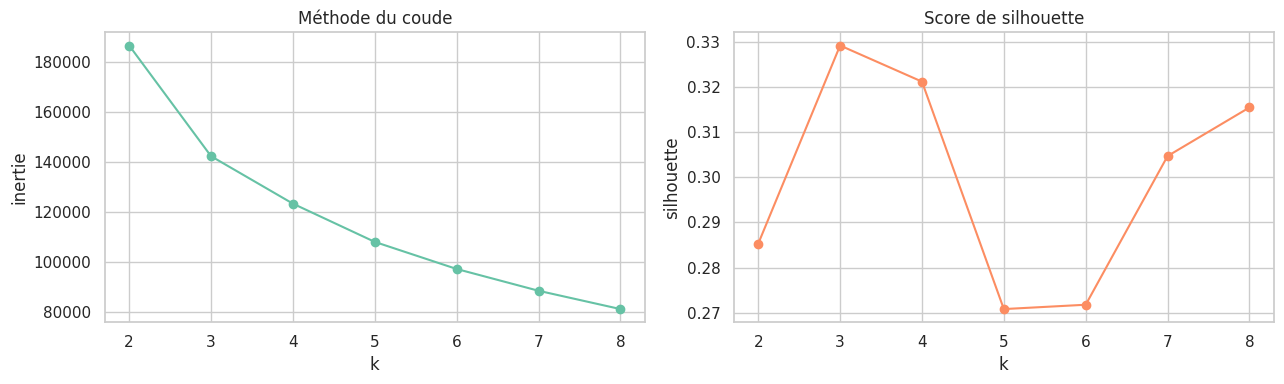

,inertie,silhouette
2,186584.0,0.285
3,142238.0,0.329
4,123226.0,0.321
5,107906.0,0.271
6,97055.0,0.272
7,88330.0,0.305
8,80995.0,0.315


In [52]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_seg), size=10_000, replace=False)   # échantillon pour la silhouette

k_values = range(2, 9)
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg[sample_idx], km.labels_[sample_idx]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(k_values), inertias, "o-")
ax[0].set_title("Méthode du coude")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertie")
ax[1].plot(list(k_values), silhouettes, "o-", color="#fc8d62")
ax[1].set_title("Score de silhouette")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

pd.DataFrame({"inertie": np.round(inertias), "silhouette": np.round(silhouettes, 3)}, index=list(k_values))

**Choix : k = 4.**
- La silhouette est maximale pour k = 3 ou 4 (les deux scores sont presque identiques), puis elle chute à k = 5.
- Le coude se situe vers k = 3 / 4 : au-delà, ajouter un segment réduit peu l'inertie.
- Entre 3 et 4, on préfère **4 segments** : c'est un nombre que l'équipe marketing peut gérer, et le
  quatrième segment (les seniors) correspond à un vrai besoin bancaire distinct (préparation de la retraite).

Le score de silhouette (~0,32) est modéré, ce qui est normal sur des données humaines : les profils se
chevauchent, il n'existe pas de frontières nettes entre « types » de personnes. L'important est que les
segments soient **interprétables et utiles**, ce que l'on vérifie ci-dessous.

### 5.4 Segmentation finale avec K-Means

In [53]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
df_clean["cluster"] = kmeans.labels_

# Profil moyen de chaque cluster (sur les données lisibles de df_clean)
profil = df_clean.groupby("cluster").agg(
    effectif=("age", "size"),
    age_moyen=("age", "mean"),
    education_moy=("education_num", "mean"),
    heures_moy=("hours_per_week", "mean"),
    pct_marie=("is_married", "mean"),
    pct_capital=("has_capital", "mean"),
    pct_hauts_revenus=("income_high", "mean"),
)

# Nommage automatique des segments à partir de leur profil
# (les numéros 0..3 donnés par K-Means sont arbitraires et peuvent changer d'une version à l'autre)
noms = {}
reste = profil.copy()
c = reste["pct_capital"].idxmax();   noms[c] = "Investisseurs";               reste = reste.drop(c)
c = reste["age_moyen"].idxmax();     noms[c] = "Seniors";                     reste = reste.drop(c)
c = reste["pct_marie"].idxmin();     noms[c] = "Jeunes actifs célibataires";  reste = reste.drop(c)
c = reste.index[0];                  noms[c] = "Actifs établis en couple"

df_clean["segment"] = df_clean["cluster"].map(noms)
profil.index = profil.index.map(noms)
profil["part_population"] = profil["effectif"] / profil["effectif"].sum()

ordre = ["Investisseurs", "Actifs établis en couple", "Seniors", "Jeunes actifs célibataires"]
profil = profil.loc[ordre]

# Affichage lisible : pourcentages en %
affichage = profil.copy()
for col in ["pct_marie", "pct_capital", "pct_hauts_revenus", "part_population"]:
    affichage[col] = (affichage[col] * 100).round(1)
affichage.round(1)

,effectif,age_moyen,education_moy,heures_moy,pct_marie,pct_capital,pct_hauts_revenus,part_population
cluster,,,,,,,,
Investisseurs,3968,44.2,11.1,43.9,67.5,100.0,62.8,8.1
Actifs établis en couple,16516,40.1,10.8,45.8,98.1,7.6,44.6,33.9
Seniors,7396,57.5,8.0,34.5,46.9,4.7,12.5,15.2
Jeunes actifs célibataires,20906,29.8,10.1,37.6,0.2,3.6,4.3,42.9


In [54]:
# Description complémentaire : secteur et métier les plus fréquents par segment
def top_modalites(s, n=2):
    vc = s.value_counts(normalize=True).head(n)
    return ", ".join(f"{m} ({p:.0%})" for m, p in vc.items())

desc = df_clean.groupby("segment").agg(
    metiers_principaux=("occupation", top_modalites),
    secteurs_principaux=("workclass", top_modalites),
    tranche_age_principale=("age_group", lambda s: top_modalites(s.astype(str), 1)),
    niveau_etudes_principal=("education_level", lambda s: top_modalites(s.astype(str), 1)),
).loc[ordre]
desc

,metiers_principaux,secteurs_principaux,tranche_age_principale,niveau_etudes_principal
segment,,,,
Investisseurs,"Prof-specialty (21%), Exec-managerial (20%)","Private (64%), State-Local-gov (11%)",36-45 (30%),HS-grad (26%)
Actifs établis en couple,"Craft-repair (17%), Exec-managerial (17%)","Private (66%), State-Local-gov (12%)",36-45 (35%),HS-grad (33%)
Seniors,"Other-service (14%), Craft-repair (12%)","Private (62%), Unknown (12%)",56-65 (39%),HS-grad (39%)
Jeunes actifs célibataires,"Adm-clerical (15%), Other-service (14%)","Private (75%), State-Local-gov (10%)",17-25 (40%),Some-college-Assoc (35%)


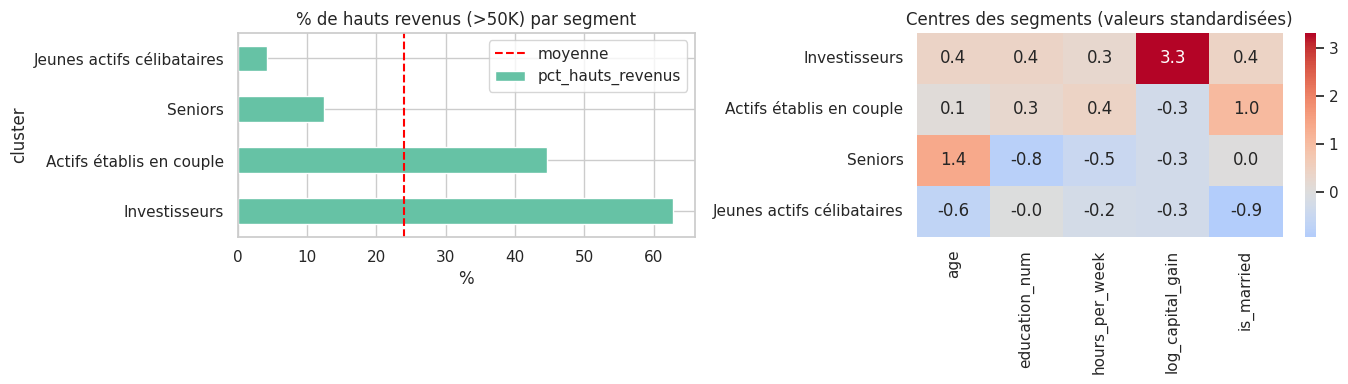

In [55]:
# Taux de hauts revenus par segment (le revenu n'a PAS servi à construire les segments)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(profil["pct_hauts_revenus"] * 100).plot(kind="barh", ax=ax[0], color="#66c2a5")
ax[0].axvline(df_clean["income_high"].mean() * 100, color="red", linestyle="--", label="moyenne")
ax[0].set_title("% de hauts revenus (>50K) par segment")
ax[0].set_xlabel("%"); ax[0].legend()

# Profil standardisé des centres : lecture rapide de ce qui distingue chaque segment
centres = pd.DataFrame(kmeans.cluster_centers_, columns=seg_features)
centres.index = centres.index.map(noms)
sns.heatmap(centres.loc[ordre], annot=True, fmt=".1f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Centres des segments (valeurs standardisées)")
plt.tight_layout()
plt.show()

In [56]:
# Poids business : quelle part des hauts revenus se trouve dans chaque segment ?
poids = pd.DataFrame({
    "% de la population": profil["part_population"] * 100,
    "% des hauts revenus de la population": df_clean.groupby("segment")["income_high"].sum().loc[ordre]
                                             / df_clean["income_high"].sum() * 100,
}).round(1)
poids

,% de la population,% des hauts revenus de la population
Investisseurs,8.1,21.3
Actifs établis en couple,33.9,63.1
Seniors,15.2,7.9
Jeunes actifs célibataires,42.9,7.7


**Lecture des heatmaps** : une valeur positive signifie « au-dessus de la moyenne », négative « en dessous ».
Exemple : les Investisseurs ont une valeur très élevée sur `log_capital_gain`, les Seniors sur `age`.

**Résultat clé pour la banque** : les segments *Investisseurs* et *Actifs établis en couple* regroupent
**environ 4 personnes sur 10, mais plus de 8 hauts revenus sur 10**. En concentrant les campagnes premium
sur ces deux segments, la banque toucherait l'essentiel de sa cible en sollicitant moins de la moitié des
prospects. C'est exactement l'objectif BO2 (réduire les coûts marketing).

### 5.5 Comparaison avec une autre méthode : la classification ascendante hiérarchique (CAH)

Pour vérifier que les segments ne dépendent pas de l'algorithme choisi, on compare avec la **CAH**
(méthode de Ward), qui regroupe les individus pas à pas, des plus proches aux plus éloignés.
La CAH doit calculer toutes les distances entre paires d'individus : sur 48 000 lignes, cela représente plus
d'un milliard de distances, ce qui est trop lourd. On la lance donc sur un **échantillon de 5 000 individus**.

L'**indice de Rand ajusté (ARI)** mesure l'accord entre les deux partitions : 1 = identiques, 0 = accord dû au hasard.

In [57]:
idx_cah = rng.choice(len(X_seg), size=5_000, replace=False)
X_cah = X_seg[idx_cah]

cah = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X_cah)
labels_km = kmeans.labels_[idx_cah]

comparaison_algo = pd.DataFrame({
    "silhouette (échantillon)": [silhouette_score(X_cah, labels_km), silhouette_score(X_cah, cah.labels_)],
}, index=["K-Means", "CAH (Ward)"]).round(3)
display(comparaison_algo)
print("Accord entre les deux méthodes (ARI) :", round(adjusted_rand_score(labels_km, cah.labels_), 3))

# Tableau croisé : chaque segment K-Means correspond-il à un groupe CAH ?
pd.crosstab(pd.Series(labels_km).map(noms).rename("K-Means"),
            pd.Series(cah.labels_).rename("CAH (groupe)"))

,silhouette (échantillon)
K-Means,0.322
CAH (Ward),0.314


Accord entre les deux méthodes (ARI) : 0.731


CAH (groupe),0,1,2,3
K-Means,,,,
Actifs établis en couple,83,1529,46,0
Investisseurs,0,0,0,414
Jeunes actifs célibataires,2078,5,73,6
Seniors,232,147,384,3


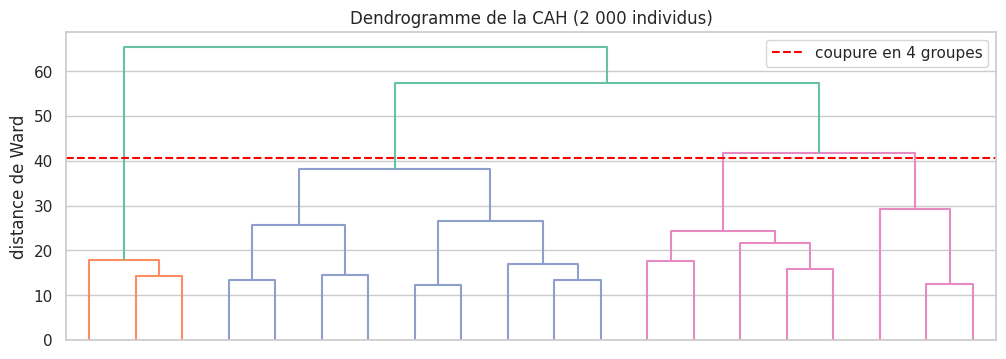

In [58]:
# Dendrogramme sur un petit échantillon (lisibilité)
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_cah[:2000], method="ward")
plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode="lastp", p=20, no_labels=True)
plt.axhline(y=Z[-K + 1, 2] - 1, color="red", linestyle="--", label=f"coupure en {K} groupes")
plt.title("Dendrogramme de la CAH (2 000 individus)")
plt.ylabel("distance de Ward")
plt.legend()
plt.show()

**Conclusion de la comparaison**
- Les deux méthodes trouvent **en grande partie les mêmes groupes** (ARI ~0,7, un accord élevé) : la segmentation
  est robuste, elle ne dépend pas de l'algorithme. Le tableau croisé montre que les Investisseurs, les Jeunes
  célibataires et les Actifs en couple se retrouvent presque à l'identique ; les **Seniors** sont le segment le
  moins stable, réparti entre plusieurs groupes de la CAH (c'est un segment plus hétérogène : actifs âgés et retraités).
- K-Means obtient une silhouette légèrement meilleure (~0,32 contre ~0,31).
- K-Means **passe à l'échelle** sur les 48 000 individus, et peut affecter un **nouveau prospect** à un segment
  avec `kmeans.predict()`, ce qui est indispensable pour une utilisation en production par la banque.
  La CAH ne permet ni l'un ni l'autre.

**K-Means est donc retenu.**

### 5.6 Visualisation des segments (ACP)

Part de l'information conservée par les 2 axes : 52%


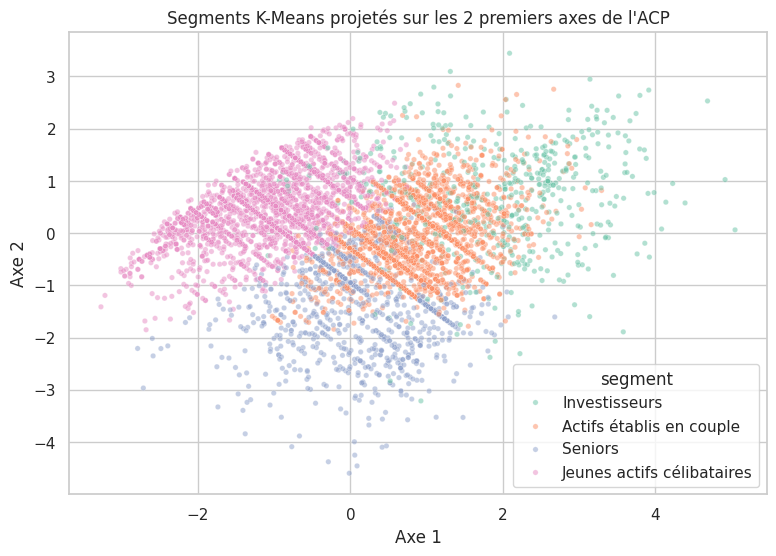

,Axe 1,Axe 2
age,0.49,-0.53
education_num,0.31,0.69
hours_per_week,0.43,0.32
log_capital_gain,0.38,0.22
is_married,0.58,-0.31


In [59]:
# L'ACP projette les 5 dimensions sur 2 axes pour pouvoir dessiner les segments
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_seg)
print("Part de l'information conservée par les 2 axes :", f"{pca.explained_variance_ratio_.sum():.0%}")

plot_df = pd.DataFrame(coords, columns=["Axe 1", "Axe 2"])
plot_df["segment"] = df_clean["segment"].values
plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df.sample(6000, random_state=RANDOM_STATE), x="Axe 1", y="Axe 2",
                hue="segment", hue_order=ordre, alpha=0.5, s=15)
plt.title("Segments K-Means projetés sur les 2 premiers axes de l'ACP")
plt.show()

# Contribution des variables aux axes
pd.DataFrame(pca.components_.T, index=seg_features, columns=["Axe 1", "Axe 2"]).round(2)

Les 2 axes conservent environ la moitié de l'information (52 %) : les segments se chevauchent donc un peu sur
le graphique, alors qu'ils sont mieux séparés dans l'espace complet. Le tableau des contributions permet de
lire les axes :
- **Axe 1 : « maturité financière »**. Toutes les variables y contribuent positivement (âge, mariage, heures,
  capital) : les **Jeunes célibataires** sont à gauche, les **Actifs en couple** au centre et les
  **Investisseurs** à droite.
- **Axe 2 : diplôme contre âge**. `education_num` tire vers le haut, `age` vers le bas : les **Seniors**, plus âgés
  et moins diplômés, se détachent en bas du graphique.

Les quatre segments occupent donc des zones distinctes : la segmentation a une structure claire.

### 5.7 Interprétation métier : une offre par segment

| Segment | Profil type | Hauts revenus | Offre recommandée pour la banque |
|---|---|---|---|
| **Investisseurs** | ~44 ans, un peu plus diplômés que la moyenne, tous ont des plus-values, ~4 sur 10 sont cadres | ~63 % | **gestion de patrimoine**, placements, conseiller dédié : cible n° 1 |
| **Actifs établis en couple** | ~40 ans, mariés, temps plein voire plus (~46 h), artisans et cadres | ~45 % | **carte premium**, crédit immobilier, assurance-vie : cible n° 2, la plus grande en volume |
| **Seniors** | ~57 ans, moins diplômés, moins d'heures (~34 h), une partie de retraités | ~12 % | épargne retraite, offres simples ; pas une cible premium |
| **Jeunes actifs célibataires** | ~30 ans, célibataires, en début de carrière | ~4 % | offres d'entrée de gamme (compte jeune, premier crédit) pour les **fidéliser** : futurs clients premium |

*Les valeurs exactes sont dans les tableaux ci-dessus.*

**Lien avec les objectifs** : BO3 (personnalisation) est atteint avec 4 segments clairs et une offre chacun ;
BO1 et BO2 sont soutenus, puisque deux segments concentrent l'essentiel des hauts revenus.

## 6. Classification

### 6.1 Problématique et protocole

**Objectif (DSO1)** : prédire si un prospect a un revenu supérieur à 50K (`income_high = 1`), pour que la
banque ne contacte que les prospects à fort potentiel.

**Protocole**
- Données : `df_prep` (= `adult_prepared.csv`), déjà encodées et standardisées (ajustées sur le train).
- **Train** = lignes `source == "train"`, **test** = lignes `source == "test"` (découpage officiel UCI).
- Les hyperparamètres sont choisis par **validation croisée à 5 plis sur le train uniquement**.
  Le test n'est utilisé **qu'une fois, à la fin**, pour l'évaluation : il joue le rôle de nouveaux prospects jamais vus.
- **Métriques** : rappel, précision, F1 et AUC de la classe `>50K`. L'accuracy est affichée mais n'est pas
  le critère de décision (classes déséquilibrées).

| Métrique | Question à laquelle elle répond pour la banque |
|---|---|
| **Rappel** | parmi les vrais hauts revenus, quelle part le modèle retrouve-t-il ? (prospects non manqués) |
| **Précision** | parmi les prospects que le modèle désigne, quelle part sont vraiment des hauts revenus ? (contacts utiles) |
| **F1** | compromis entre rappel et précision |
| **AUC** | capacité globale à classer un haut revenu au-dessus d'un bas revenu, quel que soit le seuil |

In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             precision_recall_curve)

features_all = [c for c in df_prep.columns if c not in ("income_high", "source")]
is_tr = df_prep["source"] == "train"

X_train, y_train = df_prep.loc[is_tr, features_all], df_prep.loc[is_tr, "income_high"]
X_test, y_test = df_prep.loc[~is_tr, features_all], df_prep.loc[~is_tr, "income_high"]
print("Train :", X_train.shape, "| % de >50K :", f"{y_train.mean():.1%}")
print("Test  :", X_test.shape, "| % de >50K :", f"{y_test.mean():.1%}")

# Validation croisée stratifiée : chaque pli garde la même proportion de >50K
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def scores(y_true, y_pred, y_proba):
    # Calcule toutes les métriques d'un modèle sur un jeu de données
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "précision": precision_score(y_true, y_pred, zero_division=0),
        "rappel": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba),
    }

resultats = {}   # on y stocke les scores de tous les modèles sur le test

Train : (32534, 49) | % de >50K : 24.1%
Test  : (16252, 49) | % de >50K : 23.6%


### 6.2 Modèle de référence (baseline)

Un modèle « naïf » qui prédit toujours la classe majoritaire (`<=50K`). Tout vrai modèle doit faire mieux.

In [61]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
resultats["Baseline (toujours <=50K)"] = scores(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])
pd.DataFrame(resultats).T.round(3)

,accuracy,précision,rappel,F1,AUC
Baseline (toujours <=50K),0.764,0.0,0.0,0.0,0.5


Ce modèle a **~76 % d'accuracy sans rien avoir appris**, mais un rappel de 0 : il ne trouve aucun prospect.
C'est la preuve que l'accuracy est trompeuse ici, et que le rappel et le F1 sont les bons critères.

### 6.3 Gestion du déséquilibre des classes

Avec seulement ~24 % de `>50K`, un modèle a tendance à favoriser la classe majoritaire. Deux solutions :
- **SMOTE** : créer des individus `>50K` artificiels. Inconvénient ici : sur des colonnes one-hot, SMOTE
  fabrique des valeurs comme « 0,4 Sales + 0,6 Craft-repair » qui ne correspondent à aucune personne réelle.
- **`class_weight="balanced"`** ✅ : on ne change pas les données, on donne plus de poids aux erreurs sur la
  classe minoritaire pendant l'apprentissage. Plus simple et sans données artificielles.

Démonstration avec la régression logistique :

In [62]:
demo = {}
for cw in [None, "balanced"]:
    m = LogisticRegression(max_iter=2000, class_weight=cw).fit(X_train, y_train)
    demo[f"class_weight={cw}"] = scores(y_test, m.predict(X_test), m.predict_proba(X_test)[:, 1])
pd.DataFrame(demo).T.round(3)

,accuracy,précision,rappel,F1,AUC
class_weight=None,0.854,0.732,0.601,0.660,0.906
class_weight=balanced,0.809,0.564,0.845,0.676,0.906


Avec `class_weight="balanced"`, le **rappel passe d'environ 60 % à environ 85 %** : le modèle retrouve beaucoup
plus de prospects à haut revenu. La précision baisse (plus de faux positifs) et l'accuracy aussi, mais pour la
banque, manquer un bon prospect coûte plus cher qu'envoyer une offre de trop. L'AUC ne change pas : le modèle
classe les individus de la même façon, seul le point de décision s'est déplacé.

**Choix : `class_weight="balanced"` pour tous les modèles qui le permettent.**

### 6.4 Entraînement et réglage de plusieurs modèles

On compare quatre modèles étudiés en cours, de nature différente :

| Modèle | Principe | Intérêt |
|---|---|---|
| **Régression logistique** | combinaison linéaire des variables → probabilité | simple, rapide, interprétable (coefficients) |
| **K plus proches voisins (KNN)** | vote des k individus les plus ressemblants | aucune hypothèse sur la forme des données |
| **Arbre de décision** | suite de questions oui / non | très lisible, capte les effets non linéaires (âge en cloche) |
| **Random Forest** | vote de centaines d'arbres différents | en général plus performant et plus stable qu'un arbre seul |

Les hyperparamètres sont choisis par `GridSearchCV` : il teste chaque combinaison en validation croisée sur le
train et garde celle qui maximise le **F1** (compromis rappel / précision).
*Cette cellule prend 2 à 4 minutes sur Colab.*

In [63]:
modeles = {
    "Régression logistique": (
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        {"C": [0.01, 0.1, 1, 10]},                       # force de la régularisation
    ),
    "KNN": (
        KNeighborsClassifier(),                          # pas de class_weight possible pour KNN
        {"n_neighbors": [15, 31, 51]},                   # nombre de voisins
    ),
    "Arbre de décision": (
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"max_depth": [6, 8, 10, 12], "min_samples_leaf": [20, 50]},   # limitent le surapprentissage
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1),
        {"max_depth": [10, 15, None], "min_samples_leaf": [1, 5]},
    ),
}

meilleurs = {}
for nom, (modele, grille) in modeles.items():
    gs = GridSearchCV(modele, grille, scoring="f1", cv=cv, n_jobs=-1).fit(X_train, y_train)
    meilleurs[nom] = gs.best_estimator_
    proba = gs.best_estimator_.predict_proba(X_test)[:, 1]
    resultats[nom] = scores(y_test, gs.best_estimator_.predict(X_test), proba)
    print(f"{nom:22s} meilleurs paramètres : {gs.best_params_}  | F1 en validation croisée : {gs.best_score_:.3f}")

tableau = pd.DataFrame(resultats).T.round(3)
tableau

Régression logistique  meilleurs paramètres : {'C': 10}  | F1 en validation croisée : 0.686


KNN                    meilleurs paramètres : {'n_neighbors': 31}  | F1 en validation croisée : 0.664


Arbre de décision      meilleurs paramètres : {'max_depth': 8, 'min_samples_leaf': 20}  | F1 en validation croisée : 0.678


Random Forest          meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 5}  | F1 en validation croisée : 0.705


,accuracy,précision,rappel,F1,AUC
Baseline (toujours <=50K),0.764,0.000,0.000,0.000,0.500
Régression logistique,0.810,0.566,0.845,0.678,0.907
KNN,0.848,0.697,0.632,0.663,0.898
Arbre de décision,0.808,0.561,0.855,0.677,0.906
Random Forest,0.830,0.601,0.839,0.700,0.919


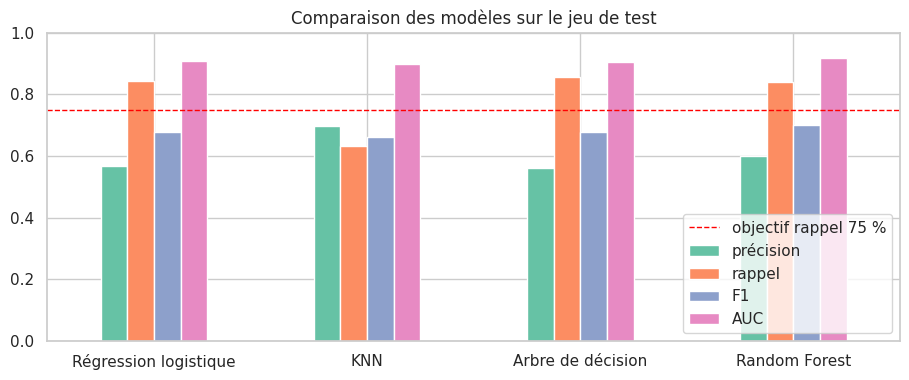

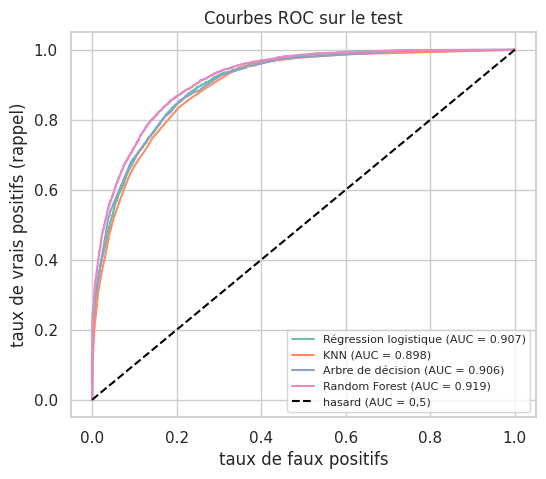

In [64]:
# Comparaison visuelle des métriques sur le test
tableau.drop(index="Baseline (toujours <=50K)")[["précision", "rappel", "F1", "AUC"]].plot(
    kind="bar", figsize=(11, 4), ylim=(0, 1), rot=0)
plt.title("Comparaison des modèles sur le jeu de test")
plt.axhline(0.75, color="red", linestyle="--", linewidth=1, label="objectif rappel 75 %")
plt.legend(loc="lower right")
plt.show()

# Courbes ROC
plt.figure(figsize=(6, 5))
for nom, m in meilleurs.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {resultats[nom]['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="hasard (AUC = 0,5)")
plt.xlabel("taux de faux positifs"); plt.ylabel("taux de vrais positifs (rappel)")
plt.title("Courbes ROC sur le test")
plt.legend(fontsize=8)
plt.show()

**Interprétation**
- **Tous les modèles font bien mieux que la baseline** (AUC ~0,90 à 0,92 contre 0,5).
- **Le Random Forest est le meilleur** sur les deux critères globaux : F1 ≈ 0,70 et AUC ≈ 0,92. En combinant des
  centaines d'arbres, il capte les effets non linéaires (revenu en cloche selon l'âge) et les interactions
  (par exemple diplôme × métier) que la régression logistique ne voit pas.
- La **régression logistique** et l'**arbre de décision** sont juste derrière (F1 ≈ 0,68, AUC ≈ 0,91), avec un
  très bon rappel (~85 %) mais une précision plus faible (~56 %) : ils désignent beaucoup de prospects, dont
  près de la moitié à tort. La régression logistique reste intéressante pour sa simplicité et son interprétabilité.
- Le **KNN** a la meilleure précision (~70 %) mais le plus faible rappel (~63 %) : il ne gère pas le déséquilibre
  des classes (pas de `class_weight`), donc il favorise la classe majoritaire et rate plus d'un tiers des prospects.
  Il ne respecte pas le critère de rappel de 75 %.

**Modèle retenu : Random Forest.** On ajuste ensuite son seuil de décision pour coller au besoin de la banque.

### 6.5 Choix du seuil de décision

Par défaut, un modèle prédit `>50K` quand la probabilité dépasse **0,5**. Mais ce seuil n'a rien d'obligatoire :
on peut le régler selon le besoin métier. Le critère de succès fixé est un **rappel ≥ 75 %**. Parmi les seuils
qui respectent ce rappel, on choisit celui qui donne la **meilleure précision**, c'est-à-dire le moins de
contacts inutiles.

**Marge de sécurité** : le rappel mesuré sur le train varie un peu sur de nouvelles données. Si l'on vise
exactement 75 % sur le train, on a environ une chance sur deux de tomber juste en dessous sur de nouveaux
prospects. On vise donc **77 %** sur le train (marge de 2 points) pour garantir l'objectif en conditions réelles.

Pour ne pas « tricher », le seuil est choisi à partir de prédictions en **validation croisée sur le train**
(`cross_val_predict`), puis appliqué tel quel au test.

Seuil retenu : 0.590


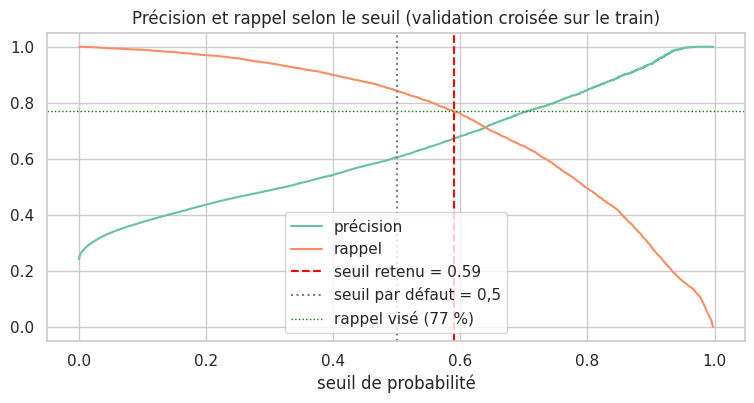

In [65]:
best_rf = meilleurs["Random Forest"]

# Probabilités "hors échantillon" sur le train : chaque ligne est prédite par un modèle qui ne l'a pas vue
proba_cv = cross_val_predict(best_rf, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

prec, rec, seuils = precision_recall_curve(y_train, proba_cv)
prec, rec = prec[:-1], rec[:-1]               # alignement des tableaux avec les seuils

OBJECTIF_RAPPEL = 0.75          # critère de succès métier
MARGE = 0.02                    # marge de sécurité
ok = rec >= OBJECTIF_RAPPEL + MARGE
seuil_opt = seuils[ok][np.argmax(prec[ok])]   # meilleure précision parmi les seuils qui respectent le rappel
print(f"Seuil retenu : {seuil_opt:.3f}")

plt.figure(figsize=(9, 4))
plt.plot(seuils, prec, label="précision")
plt.plot(seuils, rec, label="rappel")
plt.axvline(seuil_opt, color="red", linestyle="--", label=f"seuil retenu = {seuil_opt:.2f}")
plt.axvline(0.5, color="grey", linestyle=":", label="seuil par défaut = 0,5")
plt.axhline(OBJECTIF_RAPPEL + MARGE, color="green", linestyle=":", linewidth=1, label="rappel visé (77 %)")
plt.xlabel("seuil de probabilité"); plt.title("Précision et rappel selon le seuil (validation croisée sur le train)")
plt.legend()
plt.show()

In [66]:
proba_test = best_rf.predict_proba(X_test)[:, 1]
resultats["Random Forest (seuil ajusté)"] = scores(y_test, (proba_test >= seuil_opt).astype(int), proba_test)
pd.DataFrame(resultats).T.loc[["Random Forest", "Random Forest (seuil ajusté)"]].round(3)

,accuracy,précision,rappel,F1,AUC
Random Forest,0.830,0.601,0.839,0.700,0.919
Random Forest (seuil ajusté),0.854,0.667,0.762,0.711,0.919


**Effet du seuil ajusté (~0,59 au lieu de 0,5)**
- Le **rappel** passe d'environ 84 % à **76 %** : il reste au-dessus de l'objectif de 75 %.
- La **précision** passe d'environ 60 % à **67 %** : sur 100 prospects contactés, 67 sont de vrais hauts revenus
  au lieu de 60. Ce sont des offres inutiles en moins, donc des coûts marketing en moins (BO2).
- Le **F1** s'améliore légèrement, et l'**AUC** ne change pas (normal : le seuil ne change pas la façon dont le
  modèle classe les individus, seulement la limite à partir de laquelle on dit « oui »).

Le seuil par défaut donnait un rappel inutilement élevé au prix de beaucoup de faux positifs. Le seuil ajusté
donne le **meilleur compromis compatible avec l'objectif métier**.

### 6.6 Modèle avec ou sans variables sensibles

Une banque ne peut pas sélectionner ses clients selon leur sexe, leur origine ethnique ou leur origine
géographique. On retire donc `sex`, `race`, `native_region` et `relationship` (dont les modalités
`Husband` / `Wife` révèlent le sexe), et on mesure ce que l'on perd en performance.

In [67]:
prefixes_sensibles = tuple(f"{v}_" for v in sensitive)          # ex. "sex_", "race_"...
features_ok = [c for c in features_all if not c.startswith(prefixes_sensibles)]
print(f"{len(features_all)} variables -> {len(features_ok)} sans les variables sensibles")
print("Retirées :", [c for c in features_all if c not in features_ok])

# Même modèle, mêmes hyperparamètres, seul l'ensemble de variables change
from sklearn.base import clone
rf_ok = clone(best_rf).fit(X_train[features_ok], y_train)

proba_cv_ok = cross_val_predict(clone(best_rf), X_train[features_ok], y_train, cv=cv,
                                method="predict_proba", n_jobs=-1)[:, 1]
p_ok, r_ok, s_ok = precision_recall_curve(y_train, proba_cv_ok)
p_ok, r_ok = p_ok[:-1], r_ok[:-1]
ok2 = r_ok >= OBJECTIF_RAPPEL + MARGE                 # même règle de choix du seuil qu'en 6.5
seuil_ok = s_ok[ok2][np.argmax(p_ok[ok2])]
print(f"Seuil retenu sans variables sensibles : {seuil_ok:.3f}")

proba_test_ok = rf_ok.predict_proba(X_test[features_ok])[:, 1]
resultats["Random Forest sans variables sensibles (seuil ajusté)"] = scores(
    y_test, (proba_test_ok >= seuil_ok).astype(int), proba_test_ok)

pd.DataFrame(resultats).T.loc[["Random Forest (seuil ajusté)",
                               "Random Forest sans variables sensibles (seuil ajusté)"]].round(3)

49 variables -> 31 sans les variables sensibles
Retirées : ['relationship_Husband', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'native_region_Asia', 'native_region_Europe-Canada', 'native_region_Latin-America', 'native_region_Other', 'native_region_United-States', 'native_region_Unknown', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'sex_Male']


Seuil retenu sans variables sensibles : 0.575


,accuracy,précision,rappel,F1,AUC
Random Forest (seuil ajusté),0.854,0.667,0.762,0.711,0.919
Random Forest sans variables sensibles (seuil ajusté),0.853,0.663,0.765,0.711,0.918


In [68]:
# Le modèle sans variables sensibles traite-t-il les femmes et les hommes de façon équilibrée ?
sexe_test = df_clean.loc[df_clean["source"] == "test", "sex"].values
pred_ok = (proba_test_ok >= seuil_ok).astype(int)
equite = pd.DataFrame({
    "% de vrais >50K": pd.Series(y_test.values).groupby(sexe_test).mean(),
    "% désignés par le modèle": pd.Series(pred_ok).groupby(sexe_test).mean(),
    "rappel": pd.Series([recall_score(y_test.values[sexe_test == s], pred_ok[sexe_test == s])
                         for s in ["Female", "Male"]], index=["Female", "Male"]),
}).mul(100).round(1)
equite

,% de vrais >50K,% désignés par le modèle,rappel
Female,10.9,10.5,65.6
Male,30.0,35.7,78.5


**Interprétation**
- Retirer les 18 colonnes sensibles **ne fait quasiment rien perdre** : F1 ≈ 0,71 et AUC ≈ 0,92 dans les deux cas,
  rappel toujours au-dessus de 75 %. Ces variables n'apportaient presque rien en plus des variables
  professionnelles (diplôme, métier, heures, capital, situation familiale). Il n'y a donc **aucune raison
  métier de les garder** : le modèle final est le Random Forest **sans variables sensibles**.
- **Mais retirer une variable ne suffit pas à garantir l'équité.** Le deuxième tableau montre que le modèle
  retrouve environ 66 % des femmes à haut revenu, contre environ 79 % des hommes. Le modèle ne connaît pas le sexe,
  mais d'autres variables y sont liées dans les données de 1994 (métiers, heures travaillées, situation
  familiale) : on parle de **variables « proxy »**. Les femmes à haut revenu ont des profils moins « typiques »
  de ce que le modèle a appris, il les repère donc moins bien.
- **Recommandation** : en production, la banque devrait **contrôler régulièrement les résultats par groupe**
  (rappel, taux de sélection), et éventuellement ajuster les seuils par groupe ou utiliser des méthodes
  d'apprentissage équitable. C'est une limite importante à signaler.

### 6.7 Interprétation du modèle final : quelles variables comptent ?

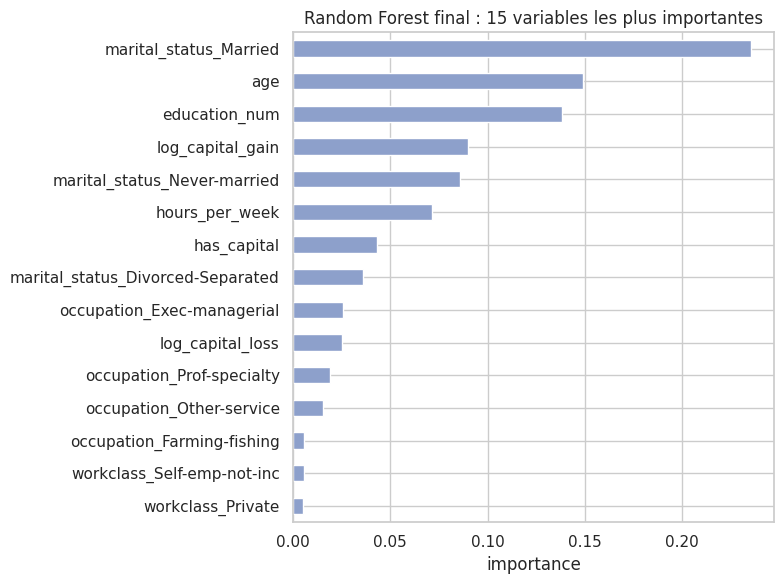

In [69]:
importances = pd.Series(rf_ok.feature_importances_, index=features_ok).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="#8da0cb")
plt.title("Random Forest final : 15 variables les plus importantes")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

In [70]:
# La régression logistique donne en plus le SENS de l'effet (+ = augmente la probabilité de >50K).
# On retire has_capital : elle est presque redondante avec log_capital_gain / log_capital_loss
# (multicolinéarité), ce qui rendrait les coefficients de ces variables instables et trompeurs.
features_lr = [c for c in features_ok if c != "has_capital"]
lr_ok = clone(meilleurs["Régression logistique"]).fit(X_train[features_lr], y_train)
coefs = pd.Series(lr_ok.coef_[0], index=features_lr).sort_values()
pd.concat([coefs.head(6), coefs.tail(6)]).to_frame("coefficient").round(2)

,coefficient
occupation_Priv-house-serv,-2.78
marital_status_Never-married,-1.16
workclass_No-income,-1.07
occupation_Farming-fishing,-0.90
marital_status_Widowed,-0.78
marital_status_Divorced-Separated,-0.75
occupation_Prof-specialty,0.75
occupation_Tech-support,0.76
education_num,0.76
occupation_Protective-serv,0.86


**Interprétation**
- **Situation familiale** (`marital_status_Married`, `Never-married`) : variable la plus importante. Être marié
  est fortement associé au haut revenu (coefficient le plus positif) et être célibataire le plus négatif.
  Le mariage reflète en partie l'âge et la stabilité professionnelle. Prudence : dans ces données, il est
  aussi lié au sexe (environ 60 % des hommes sont mariés contre environ 15 % des femmes), ce qui contribue à
  l'écart observé en 6.6.
- **Âge** et **diplôme** (`education_num`) : les deux variables numériques les plus importantes, conformément à
  l'exploration (revenu plus élevé avec l'expérience et les études).
- **Capital** (`log_capital_gain`, `has_capital`) : posséder du capital est un signal fort, ce qui rejoint le
  segment des Investisseurs.
- **Heures travaillées** et **métiers** de cadre (`Exec-managerial`, `Prof-specialty`) augmentent la probabilité ;
  les métiers de service (`Priv-house-serv`, `Other-service`) et l'absence de revenu du travail la diminuent.

Ces résultats sont **cohérents avec l'exploration** de la partie 3 : le modèle s'appuie sur des facteurs
logiques et explicables, ce qui est rassurant avant de l'utiliser pour des décisions commerciales.

*Note : l'importance du Random Forest dit à quel point une variable est utile, pas dans quel sens elle agit ;
c'est pourquoi on la complète par les coefficients de la régression logistique.*

### 6.8 Matrice de confusion du modèle final

Traduite en langage métier, sur les ~16 000 prospects du test.

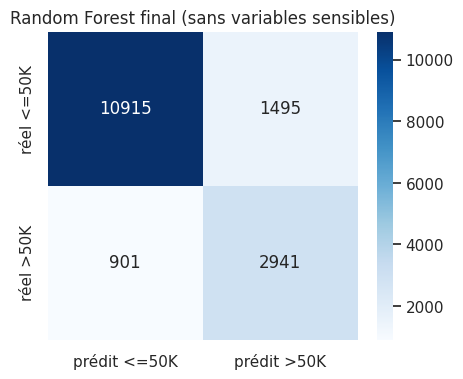

Prospects contactés (prédits >50K)      : 4436  (27% des prospects)
  dont vrais hauts revenus (contacts utiles) : 2941
  dont faux positifs (offres inutiles)       : 1495
Hauts revenus manqués (faux négatifs)    : 901

Sans modèle, contacter tout le monde : 16252 contacts pour 3842 hauts revenus (taux de réussite 24%)
Avec le modèle : taux de réussite des contacts = 66%


In [71]:
cm = confusion_matrix(y_test, pred_ok)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["prédit <=50K", "prédit >50K"], yticklabels=["réel <=50K", "réel >50K"])
plt.title("Random Forest final (sans variables sensibles)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Prospects contactés (prédits >50K)      : {tp + fp}  ({(tp + fp) / len(y_test):.0%} des prospects)")
print(f"  dont vrais hauts revenus (contacts utiles) : {tp}")
print(f"  dont faux positifs (offres inutiles)       : {fp}")
print(f"Hauts revenus manqués (faux négatifs)    : {fn}")
print(f"\nSans modèle, contacter tout le monde : {len(y_test)} contacts pour {y_test.sum()} hauts revenus "
      f"(taux de réussite {y_test.mean():.0%})")
print(f"Avec le modèle : taux de réussite des contacts = {tp / (tp + fp):.0%}")

**Ce que ça signifie pour la banque**
- En contactant seulement **~27 % des prospects** (ceux désignés par le modèle), la banque touche **~76 % des
  hauts revenus**.
- Le taux de réussite des contacts passe de **~24 %** (envoi à tout le monde) à **~66 %** : environ
  **2,8 fois plus efficace**.
- Les **faux positifs** (~1 500) reçoivent une offre premium qui ne leur correspond pas : coût d'envoi limité.
  Les **faux négatifs** (~900) sont des ventes potentielles manquées : c'est pourquoi on a imposé un rappel minimum.

## 7. Évaluation et interprétation des résultats

### 7.1 Les critères de succès sont-ils atteints ?

In [72]:
final = resultats["Random Forest sans variables sensibles (seuil ajusté)"]
base = resultats["Baseline (toujours <=50K)"]
pd.DataFrame({
    "critère": ["Rappel >50K ≥ 75 %", "F1 supérieur à la baseline", "AUC supérieure à la baseline",
                "Segments interprétables", "Modèle sans variables sensibles"],
    "résultat": [f"{final['rappel']:.1%}", f"{final['F1']:.3f} vs {base['F1']:.3f}",
                 f"{final['AUC']:.3f} vs {base['AUC']:.3f}", "4 segments, une offre chacun",
                 "sex, race, relationship, native_region retirées"],
    "atteint": ["✅" if final["rappel"] >= 0.75 else "❌",
                "✅" if final["F1"] > base["F1"] else "❌",
                "✅" if final["AUC"] > base["AUC"] else "❌", "✅", "✅"],
})

,critère,résultat,atteint
0,Rappel >50K ≥ 75 %,76.5%,✅
1,F1 supérieur à la baseline,0.711 vs 0.000,✅
2,AUC supérieure à la baseline,0.918 vs 0.500,✅
3,Segments interprétables,"4 segments, une offre chacun",✅
4,Modèle sans variables sensibles,"sex, race, relationship, native_region retirées",✅


In [73]:
# Tableau récapitulatif de tous les modèles testés
pd.DataFrame(resultats).T.round(3)

,accuracy,précision,rappel,F1,AUC
Baseline (toujours <=50K),0.764,0.000,0.000,0.000,0.500
Régression logistique,0.810,0.566,0.845,0.678,0.907
KNN,0.848,0.697,0.632,0.663,0.898
Arbre de décision,0.808,0.561,0.855,0.677,0.906
Random Forest,0.830,0.601,0.839,0.700,0.919
Random Forest (seuil ajusté),0.854,0.667,0.762,0.711,0.919
Random Forest sans variables sensibles (seuil ajusté),0.853,0.663,0.765,0.711,0.918


### 7.2 Réponse aux objectifs

**Exploration et préparation.** Les données présentaient des valeurs manquantes non aléatoires, des doublons,
des incohérences, des variables très asymétriques, des redondances et un déséquilibre des classes. Chaque
problème a été traité avec une méthode justifiée (partie 4), sans perdre d'information utile : seulement
0,1 % des lignes supprimées.

**Segmentation (BO3).** K-Means sur 5 variables métier non sensibles donne **4 segments** clairs et stables
(confirmés par la CAH) : Investisseurs, Actifs établis en couple, Seniors, Jeunes actifs célibataires.
Deux segments (~42 % de la population) concentrent **~84 % des hauts revenus** : ce sont les cibles prioritaires
des offres premium, avec une offre différente pour chacun.

**Classification (BO1 et BO2).** Le **Random Forest sans variables sensibles**, avec un seuil ajusté, retrouve
~76 % des hauts revenus (objectif ≥ 75 % atteint) avec une précision de ~66 % et une AUC de ~0,92.
Concrètement, la banque est près de **3 fois plus efficace** qu'en contactant tout le monde.

**Les deux approches se complètent** : le modèle de classification dit **qui** contacter, la segmentation dit
**quelle offre** lui proposer (gestion de patrimoine pour un Investisseur, carte premium et crédit pour un
Actif en couple…).

### 7.3 Limites et recommandations

**Limites**
- **Données anciennes et américaines (1994)** : les montants, les métiers et les écarts de revenus ont changé.
  Le seuil de 50K de 1994 correspond à plus de 100K aujourd'hui. Le modèle devrait être réentraîné sur des
  données récentes et locales avant toute utilisation réelle.
- **Données de recensement, pas de clients bancaires** : la banque ne dispose pas forcément de toutes ces
  informations (heures travaillées, plus-values) pour ses prospects.
- **Équité** : même sans variables sensibles, le modèle repère moins bien les femmes à haut revenu, à cause des
  variables proxy et des inégalités présentes dans les données historiques.
- **Revenu binaire** : `>50K` ne dit pas si le revenu est de 51K ou de 500K, alors que l'offre adaptée n'est
  pas la même.
- **Silhouette modérée (~0,32)** : les segments sont utiles mais leurs frontières sont floues ; certains
  individus sont à la limite entre deux segments.

**Recommandations**
1. Utiliser le modèle pour **prioriser** les prospects, puis la segmentation pour **personnaliser** l'offre.
2. Tester l'approche sur une **campagne pilote** et mesurer le vrai taux de conversion.
3. **Surveiller l'équité** du modèle par groupe et l'ajuster si nécessaire.
4. **Réentraîner** régulièrement le modèle sur des données récentes.
5. Piste d'amélioration : tester des modèles de boosting (Gradient Boosting, XGBoost) et une segmentation
   adaptée aux données mixtes (K-Prototypes) pour intégrer les métiers dans le calcul.

### 7.4 Export final et téléchargement des fichiers

On réenregistre `adult_clean.csv` pour y ajouter la colonne `segment` obtenue en partie 5 : chaque prospect
est ainsi rattaché à son segment marketing. `adult_prepared.csv` reste celui de la partie 4.
Les fichiers sont créés dans la session Colab, qui est effacée à la fermeture : la cellule ci-dessous les
télécharge sur l'ordinateur (on peut aussi les récupérer dans l'onglet 📁 Fichiers, à gauche).

In [74]:
df_clean.drop(columns="cluster").to_csv("adult_clean.csv", index=False)
print("adult_clean.csv    :", df_clean.drop(columns="cluster").shape, "(avec la colonne segment)")
print("adult_prepared.csv :", df_prep.shape)

try:
    from google.colab import files   # n'existe que dans Colab
    files.download("adult_clean.csv")
    files.download("adult_prepared.csv")
except ImportError:
    print("Hors de Colab : les fichiers sont dans le dossier du notebook.")

adult_clean.csv    : (48786, 23) (avec la colonne segment)
adult_prepared.csv : (48786, 51)
Hors de Colab : les fichiers sont dans le dossier du notebook.
